# PHÂN TÍCH DỮ LIỆU DOANH SỐ WALMART

---

## Bài toán

Phân tích yếu tố ảnh hưởng đến doanh số của 45 cửa hàng Walmart (2010-2012) để:
- Hiểu rõ các yếu tố tác động (ngày lễ, mùa vụ, quy mô, loại cửa hàng)
- Phân nhóm cửa hàng theo đặc điểm
- Thử nghiệm dự đoán tuần có doanh số cao

---

## Dữ liệu

- **Nguồn**: Kaggle - Walmart Sales Forecasting
- **Thời gian**: 02/2010 - 12/2012 (143 tuần)
- **Quy mô**: 45 cửa hàng, 421,570 records ban đầu
- **3 files**: train.csv (doanh số), features.csv (yếu tố kinh tế), stores.csv (thông tin cửa hàng)

---

## Phương pháp

1. **Chuẩn bị dữ liệu**: Load, merge, xử lý missing values, outliers
2. **Phân tích mô tả (Q1-Q6)**: Thống kê, biểu đồ, kiểm định
3. **Phân cụm - K-Means (Q7)**: Chia 45 cửa hàng thành 3 nhóm
4. **Dự đoán - Decision Tree (Q8)**: Thử nghiệm phân loại tuần cao/thấp

**Lưu ý**: Đây là phân tích mô tả và thử nghiệm, chưa tối ưu cho sản xuất.

---

## 8 Câu hỏi

**Phần I - Mô tả cơ bản**
- Q1: Doanh số phân bố như thế nào?
- Q2: Ngày lễ có làm tăng doanh số?
- Q3: Có xu hướng theo mùa không?

**Phần II - So sánh nhóm**
- Q4: Loại cửa hàng A/B/C khác nhau ra sao?
- Q5: Quy mô lớn có bán nhiều hơn?
- Q6: Yếu tố kinh tế ảnh hưởng thế nào?

**Phần III - Machine Learning**
- Q7: Chia cửa hàng thành mấy nhóm? (K-Means)
- Q8: Có dự đoán được tuần cao điểm? (Decision Tree)


In [49]:
# ===== PHẦN 0: THIẾT LẬP MÔI TRƯỜNG =====

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Cấu hình matplotlib & seaborn
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

RANDOM_STATE = 42
print("Thiet lap moi truong hoan tat!")

Thiet lap moi truong hoan tat!


---
# PHẦN 1: TIỀN XỬ LÝ DỮ LIỆU
## 1.1: Chuẩn bị dữ liệu

Làm sạch và chuẩn bị dữ liệu qua 10 bước: load files, xử lý missing values, merge datasets, tạo biến thời gian, xử lý outliers, tạo dataset tổng hợp.


In [50]:
# 1. Load dữ liệu từ 3 file CSV
train = pd.read_csv('data/train.csv')
features = pd.read_csv('data/features.csv')
stores = pd.read_csv('data/stores.csv')

print("="*90)
print("BƯỚC 1: KIỂM TRA CẤU TRÚC DỮ LIỆU")
print("="*90)

print("\nFILE 1: train.csv (Doanh số hàng tuần)")
print(f"   Kích thước: {train.shape[0]:,} dòng × {train.shape[1]} cột")
print(f"   Các cột: {', '.join(train.columns.tolist())}")
print(f"   Sample:\n{train.head(3).to_string()}")

print("\nFILE 2: features.csv (Yếu tố kinh tế)")
print(f"   Kích thước: {features.shape[0]:,} dòng × {features.shape[1]} cột")
print(f"   Các cột: {', '.join(features.columns.tolist())}")

print("\nFILE 3: stores.csv (Thông tin cửa hàng)")
print(f"   Kích thước: {stores.shape[0]:,} dòng × {stores.shape[1]} cột")
print(f"   Các cột: {', '.join(stores.columns.tolist())}")
print(f"   Sample:\n{stores.head(5).to_string()}")

BƯỚC 1: KIỂM TRA CẤU TRÚC DỮ LIỆU

FILE 1: train.csv (Doanh số hàng tuần)
   Kích thước: 421,570 dòng × 5 cột
   Các cột: Store, Dept, Date, Weekly_Sales, IsHoliday
   Sample:
   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False

FILE 2: features.csv (Yếu tố kinh tế)
   Kích thước: 8,190 dòng × 12 cột
   Các cột: Store, Date, Temperature, Fuel_Price, MarkDown1, MarkDown2, MarkDown3, MarkDown4, MarkDown5, CPI, Unemployment, IsHoliday

FILE 3: stores.csv (Thông tin cửa hàng)
   Kích thước: 45 dòng × 3 cột
   Các cột: Store, Type, Size
   Sample:
   Store Type    Size
0      1    A  151315
1      2    A  202307
2      3    B   37392
3      4    A  205863
4      5    B   34875


## 1.2 Kiểm tra Missing Values

Phát hiện cột nào thiếu dữ liệu và xử lý.


In [51]:
print("\n" + "="*90)
print("BƯỚC 2: KIỂM TRA MISSING VALUES")
print("="*90)

missing_summary = pd.DataFrame({
    'File': ['train.csv'] * len(train.columns) + ['features.csv'] * len(features.columns) + ['stores.csv'] * len(stores.columns),
    'Cột': list(train.columns) + list(features.columns) + list(stores.columns),
    'Missing (%)': [f"{train[col].isnull().sum()/len(train)*100:.2f}%" for col in train.columns] +
                   [f"{features[col].isnull().sum()/len(features)*100:.2f}%" for col in features.columns] +
                   [f"{stores[col].isnull().sum()/len(stores)*100:.2f}%" for col in stores.columns]
})

missing_summary = missing_summary[missing_summary['Missing (%)'] != '0.00%']
if len(missing_summary) > 0:
    print("\nCột có missing values:")
    print(missing_summary.to_string(index=False))
else:
    print("\nKhông có missing values trong dữ liệu chính!")

print("\nLưu ý: Các cột MarkDown có một số giá trị trống là bình thường (không phải tất cả cửa hàng đều có promotion)")


BƯỚC 2: KIỂM TRA MISSING VALUES

Cột có missing values:
        File          Cột Missing (%)
features.csv    MarkDown1      50.77%
features.csv    MarkDown2      64.33%
features.csv    MarkDown3      55.89%
features.csv    MarkDown4      57.70%
features.csv    MarkDown5      50.55%
features.csv          CPI       7.14%
features.csv Unemployment       7.14%

Lưu ý: Các cột MarkDown có một số giá trị trống là bình thường (không phải tất cả cửa hàng đều có promotion)


## 1.3 Merge datasets & tạo biến thời gian

Gộp 3 files thành 1 dataset hoàn chỉnh. Tạo thêm cột Year, Month, Quarter, Week, DayOfWeek từ Date.


In [52]:
# Merge datasets
print("\n" + "="*90)
print("BƯỚC 3: MERGE DATASETS")
print("="*90)

# Merge train + features
df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
print(f"\nMerge train + features: {df.shape[0]:,} × {df.shape[1]} cột")

# Merge với stores
df = df.merge(stores, on='Store', how='left')
print(f"Merge với stores: {df.shape[0]:,} × {df.shape[1]} cột")

# Chuẩn hóa ngày tháng
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

print(f"\nThêm cột thời gian: Year, Month, Quarter")

# Xử lý missing values cho MarkDown columns
markdown_cols = [col for col in df.columns if 'MarkDown' in col]
for col in markdown_cols:
    df[col].fillna(0, inplace=True)

print(f"Xử lý missing values: Thay MarkDown NaN = 0 (không có khuyến mãi)")
print(f"\nDATASET CUỐI CÙNG: {df.shape[0]:,} dòng × {df.shape[1]} cột")
print(f"Thời gian phủ sóng: {df['Date'].min().date()} đến {df['Date'].max().date()}")
print(f"Sample dữ liệu:\n{df.head(3).to_string()}")


BƯỚC 3: MERGE DATASETS

Merge train + features: 421,570 × 14 cột
Merge với stores: 421,570 × 16 cột

Thêm cột thời gian: Year, Month, Quarter
Xử lý missing values: Thay MarkDown NaN = 0 (không có khuyến mãi)

DATASET CUỐI CÙNG: 421,570 dòng × 19 cột
Thời gian phủ sóng: 2010-02-05 đến 2012-10-26
Sample dữ liệu:
   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment Type    Size  Year  Month  Quarter
0      1     1 2010-02-05      24924.50      False        42.31       2.572        0.0        0.0        0.0        0.0        0.0  211.096358         8.106    A  151315  2010      2        1
1      1     1 2010-02-12      46039.49       True        38.51       2.548        0.0        0.0        0.0        0.0        0.0  211.242170         8.106    A  151315  2010      2        1
2      1     1 2010-02-19      41595.55      False        39.93       2.514        0.0        0.0        0.0   

## 1.4 Kiểm tra trùng lặp

Phát hiện và xóa dòng trùng nếu có.


In [53]:
# Kiểm tra dữ liệu trùng lặp
print("\n" + "="*90)
print("BƯỚC 4: KIỂM TRA DỮ LIỆU TRÙNG LẶP")
print("="*90)

duplicates_count = df.duplicated().sum()
print(f"\nSố dòng trùng lặp: {duplicates_count:,}")

if duplicates_count > 0:
    print(f"⚠️ Phát hiện {duplicates_count:,} dòng trùng lặp ({duplicates_count/len(df)*100:.2f}%)")
    print("Đang xóa dữ liệu trùng...")
    
    # Lưu số dòng ban đầu
    original_rows = len(df)
    
    # Xóa duplicates
    df = df.drop_duplicates()
    
    # In kết quả
    removed_rows = original_rows - len(df)
    print(f"✅ Đã xóa {removed_rows:,} dòng trùng lặp")
    print(f"✅ Còn lại: {len(df):,} dòng ({len(df)/original_rows*100:.2f}% dữ liệu gốc)")
else:
    print("✅ Không có dữ liệu trùng lặp - Dataset rất sạch!")


BƯỚC 4: KIỂM TRA DỮ LIỆU TRÙNG LẶP



Số dòng trùng lặp: 0
✅ Không có dữ liệu trùng lặp - Dataset rất sạch!


## 1.5 Kiểm tra kiểu dữ liệu

Đảm bảo mỗi cột có đúng kiểu (int, float, datetime).


In [54]:
print("\n" + "="*90)
print("BƯỚC 5: KIỂM TRA & CHUYỂN ĐỔI KIỂU DỮ LIỆU")
print("="*90)

# Hiển thị kiểu dữ liệu hiện tại
print("\nKiểu dữ liệu các cột:")
dtype_summary = pd.DataFrame({
    'Cột': df.dtypes.index,
    'Kiểu Dữ Liệu': df.dtypes.values
})
print(dtype_summary.to_string(index=False))

# Chuyển đổi kiểu dữ liệu nếu cần
conversions_made = []

# Chuyển IsHoliday sang int (từ bool)
if df['IsHoliday'].dtype == 'bool':
    df['IsHoliday'] = df['IsHoliday'].astype(int)
    conversions_made.append("IsHoliday: bool → int")

# Đảm bảo Date là datetime
if not pd.api.types.is_datetime64_any_dtype(df['Date']):
    df['Date'] = pd.to_datetime(df['Date'])
    conversions_made.append("Date: object → datetime64")

if conversions_made:
    print(f"\n✅ Đã chuyển đổi {len(conversions_made)} cột:")
    for conversion in conversions_made:
        print(f"   • {conversion}")
else:
    print("\n✅ Tất cả kiểu dữ liệu đã đúng!")


BƯỚC 5: KIỂM TRA & CHUYỂN ĐỔI KIỂU DỮ LIỆU

Kiểu dữ liệu các cột:
         Cột   Kiểu Dữ Liệu
       Store          int64
        Dept          int64
        Date datetime64[ns]
Weekly_Sales        float64
   IsHoliday           bool
 Temperature        float64
  Fuel_Price        float64
   MarkDown1        float64
   MarkDown2        float64
   MarkDown3        float64
   MarkDown4        float64
   MarkDown5        float64
         CPI        float64
Unemployment        float64
        Type         object
        Size          int64
        Year          int32
       Month          int32
     Quarter          int32

✅ Đã chuyển đổi 1 cột:
   • IsHoliday: bool → int


## 1.6 Kiểm tra giá trị bất thường

Tìm doanh số âm, nhiệt độ ngoài phạm vi, giá xăng quá cao/thấp.


In [55]:
print("\n" + "="*90)
print("BƯỚC 6: KIỂM TRA PHẠM VI GIÁ TRỊ BẤT THƯỜNG")
print("="*90)

issues_found = []

# 1. Kiểm tra doanh số âm (không hợp lý)
negative_sales = (df['Weekly_Sales'] < 0).sum()
if negative_sales > 0:
    issues_found.append(f"⚠️ Có {negative_sales:,} doanh số âm!")
    print(f"\n⚠️ Cảnh báo: {negative_sales:,} dòng có Weekly_Sales < 0")
    print(df[df['Weekly_Sales'] < 0][['Store', 'Dept', 'Date', 'Weekly_Sales']].head())

# 2. Kiểm tra quy mô âm
negative_size = (df['Size'] < 0).sum()
if negative_size > 0:
    issues_found.append(f"⚠️ Có {negative_size:,} quy mô cửa hàng âm!")

# 3. Kiểm tra nhiệt độ hợp lý (Nhiệt độ ở Mỹ thường từ -20°F đến 120°F)
abnormal_temp = ((df['Temperature'] < -20) | (df['Temperature'] > 120)).sum()
if abnormal_temp > 0:
    issues_found.append(f"⚠️ Có {abnormal_temp:,} nhiệt độ bất thường!")
    print(f"\n⚠️ Cảnh báo: {abnormal_temp:,} dòng có Temperature ngoài phạm vi [-20, 120]°F")

# 4. Kiểm tra Fuel_Price hợp lý (giá xăng ở Mỹ thường $2-5/gallon)
abnormal_fuel = ((df['Fuel_Price'] < 1) | (df['Fuel_Price'] > 7)).sum()
if abnormal_fuel > 0:
    issues_found.append(f"⚠️ Có {abnormal_fuel:,} giá xăng bất thường!")

# 5. Kiểm tra Unemployment hợp lý (tỷ lệ thất nghiệp 0-30%)
abnormal_unemp = ((df['Unemployment'] < 0) | (df['Unemployment'] > 30)).sum()
if abnormal_unemp > 0:
    issues_found.append(f"⚠️ Có {abnormal_unemp:,} tỷ lệ thất nghiệp bất thường!")

# Tổng kết
if issues_found:
    print(f"\n🔴 Phát hiện {len(issues_found)} vấn đề:")
    for issue in issues_found:
        print(f"   {issue}")
    print("\n💡 Khuyến nghị: Xem xét xóa hoặc điều chỉnh các giá trị bất thường này")
else:
    print("\n✅ Tất cả giá trị trong phạm vi hợp lý!")
    print("   • Weekly_Sales: Không có giá trị âm")
    print("   • Size: Tất cả > 0")
    print("   • Temperature: Trong khoảng [-20, 120]°F")
    print("   • Fuel_Price: Trong khoảng [$1, $7]")
    print("   • Unemployment: Trong khoảng [0%, 30%]")


BƯỚC 6: KIỂM TRA PHẠM VI GIÁ TRỊ BẤT THƯỜNG

⚠️ Cảnh báo: 1,285 dòng có Weekly_Sales < 0
      Store  Dept       Date  Weekly_Sales
846       1     6 2012-08-10       -139.65
2384      1    18 2012-05-04         -1.27
6048      1    47 2010-02-19       -863.00
6049      1    47 2010-03-12       -698.00
6051      1    47 2010-10-08        -58.00

🔴 Phát hiện 1 vấn đề:
   ⚠️ Có 1,285 doanh số âm!

💡 Khuyến nghị: Xem xét xóa hoặc điều chỉnh các giá trị bất thường này


In [56]:
# BƯỚC 6.5: XỬ LÝ DOANH SỐ ÂM
print("\n" + "="*90)
print("BƯỚC 6.5: XỬ LÝ DOANH SỐ ÂM")
print("="*90)

# Kiểm tra và xóa doanh số âm
negative_count = (df['Weekly_Sales'] < 0).sum()
if negative_count > 0:
    print(f"\n⚠️ Phát hiện {negative_count:,} dòng có doanh số âm")
    print(f"   Tổng dòng trước khi xóa: {len(df):,}")
    
    # Xóa các dòng có doanh số âm
    df = df[df['Weekly_Sales'] >= 0].copy()
    
    print(f"\n🔧 ĐÃ XỬ LÝ:")
    print(f"   ✅ Đã xóa {negative_count:,} dòng có doanh số âm")
    print(f"   ✅ Còn lại: {len(df):,} dòng")
    print(f"   ✅ Giảm: {(negative_count/len(df)*100):.2f}%")
else:
    print("\n✅ Không có doanh số âm - Dữ liệu sạch!")

print("="*90)


BƯỚC 6.5: XỬ LÝ DOANH SỐ ÂM

⚠️ Phát hiện 1,285 dòng có doanh số âm
   Tổng dòng trước khi xóa: 421,570



🔧 ĐÃ XỬ LÝ:
   ✅ Đã xóa 1,285 dòng có doanh số âm
   ✅ Còn lại: 420,285 dòng
   ✅ Giảm: 0.31%


## 1.7 Tạo dataset tổng hợp

Tổng hợp doanh số theo Store và Date (cộng tất cả departments) để phân tích hiệu suất tổng thể.


In [57]:
print("\n" + "="*90)
print("BƯỚC 7: TẠO DATASET TỔNG HỢP THEO CỬA HÀNG")
print("="*90)

# Tổng hợp doanh số theo Store và Date
df_store = df.groupby(['Store', 'Date']).agg({
    'Weekly_Sales': 'sum',           # Tổng doanh số tất cả departments
    'IsHoliday': 'first',            # Giữ nguyên (giống nhau cho tất cả dept)
    'Temperature': 'first',
    'Fuel_Price': 'first',
    'CPI': 'first',
    'Unemployment': 'first',
    'Type': 'first',
    'Size': 'first',
    'Month': 'first',
    'Quarter': 'first',
    'Year': 'first'
}).reset_index()

# Đổi tên cột Weekly_Sales thành Store_Total_Sales để rõ ràng hơn
df_store.rename(columns={'Weekly_Sales': 'Store_Total_Sales'}, inplace=True)

print(f"\n📊 KẾT QUẢ:")
print(f"   Dataset gốc:  {df.shape[0]:,} records (chi tiết theo department)")
print(f"   Dataset tổng hợp:  {df_store.shape[0]:,} records (tổng hợp theo cửa hàng)")
print(f"   Giảm: {df.shape[0] - df_store.shape[0]:,} records ({(1 - df_store.shape[0]/df.shape[0])*100:.1f}%)")

print(f"\n📋 THÔNG TIN DATASET TỔNG HỢP:")
print(f"   Số cửa hàng: {df_store['Store'].nunique()}")
print(f"   Số tuần: {df_store['Date'].nunique()}")
print(f"   Khoảng thời gian: {df_store['Date'].min().date()} đến {df_store['Date'].max().date()}")
print(f"   Doanh số trung bình/tuần/cửa hàng: ${df_store['Store_Total_Sales'].mean():,.0f}")
print(f"   Doanh số trung vị: ${df_store['Store_Total_Sales'].median():,.0f}")


BƯỚC 7: TẠO DATASET TỔNG HỢP THEO CỬA HÀNG

📊 KẾT QUẢ:
   Dataset gốc:  420,285 records (chi tiết theo department)
   Dataset tổng hợp:  6,435 records (tổng hợp theo cửa hàng)
   Giảm: 413,850 records (98.5%)

📋 THÔNG TIN DATASET TỔNG HỢP:
   Số cửa hàng: 45
   Số tuần: 143
   Khoảng thời gian: 2010-02-05 đến 2012-10-26
   Doanh số trung bình/tuần/cửa hàng: $1,046,979
   Doanh số trung vị: $960,746


## 1.8 Phát hiện Outliers

Dùng phương pháp IQR (Interquartile Range) để tìm tuần có doanh số bất thường cao/thấp. Không xóa vì đây là tuần lễ quan trọng.


In [58]:
print("\n" + "="*90)
print("BƯỚC 8: PHÁT HIỆN OUTLIERS (IQR METHOD)")
print("="*90)

# Phương pháp IQR (Interquartile Range)
Q1 = df_store['Store_Total_Sales'].quantile(0.25)
Q3 = df_store['Store_Total_Sales'].quantile(0.75)
IQR = Q3 - Q1

# Ngưỡng outlier: Q1 - 1.5*IQR và Q3 + 1.5*IQR
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Tìm outliers
outliers_iqr = df_store[(df_store['Store_Total_Sales'] < lower_bound) | (df_store['Store_Total_Sales'] > upper_bound)]

print(f"\n📊 PHÂN TÍCH OUTLIERS:")
print(f"   Q1 (25%): ${Q1:,.0f}")
print(f"   Q3 (75%): ${Q3:,.0f}")
print(f"   IQR: ${IQR:,.0f}")
print(f"   Lower Bound: ${lower_bound:,.0f}")
print(f"   Upper Bound: ${upper_bound:,.0f}")

print(f"\n🔍 KẾT QUẢ:")
print(f"   Số outliers (IQR): {len(outliers_iqr):,} tuần ({len(outliers_iqr)/len(df_store)*100:.2f}%)")
print(f"   Outliers thấp (< ${lower_bound:,.0f}): {len(df_store[df_store['Store_Total_Sales'] < lower_bound]):,}")
print(f"   Outliers cao (> ${upper_bound:,.0f}): {len(df_store[df_store['Store_Total_Sales'] > upper_bound]):,}")

# Thống kê outliers cao
if len(df_store[df_store['Store_Total_Sales'] > upper_bound]) > 0:
    print(f"\n📈 TOP 5 OUTLIERS CAO NHẤT:")
    top_outliers = df_store[df_store['Store_Total_Sales'] > upper_bound].nlargest(5, 'Store_Total_Sales')[
        ['Store', 'Date', 'Store_Total_Sales', 'IsHoliday']
    ]
    print(top_outliers.to_string(index=False))
    
print(f"\n💡 GHI CHÚ VỀ OUTLIERS:")
print(f"   ❌ KHÔNG xóa outliers!")
print(f"   ✅ Đây là những tuần bán ĐẶC BIỆT (Black Friday, Christmas)")
print(f"   ✅ Giữ lại để phân tích tác động của ngày lễ lên doanh số")


BƯỚC 8: PHÁT HIỆN OUTLIERS (IQR METHOD)

📊 PHÂN TÍCH OUTLIERS:
   Q1 (25%): $553,350
   Q3 (75%): $1,420,159
   IQR: $866,809
   Lower Bound: $-746,863
   Upper Bound: $2,720,371

🔍 KẾT QUẢ:
   Số outliers (IQR): 34 tuần (0.53%)
   Outliers thấp (< $-746,863): 0
   Outliers cao (> $2,720,371): 34

📈 TOP 5 OUTLIERS CAO NHẤT:
 Store       Date  Store_Total_Sales  IsHoliday
    14 2010-12-24         3818686.45          0
    20 2010-12-24         3766687.43          0
    10 2010-12-24         3749057.69          0
     4 2011-12-23         3676388.98          0
    13 2010-12-24         3595903.20          0

💡 GHI CHÚ VỀ OUTLIERS:
   ❌ KHÔNG xóa outliers!
   ✅ Đây là những tuần bán ĐẶC BIỆT (Black Friday, Christmas)
   ✅ Giữ lại để phân tích tác động của ngày lễ lên doanh số


In [59]:
print(f"\nDATASET CUỐI CÙNG: {df_store.shape[0]:,} dòng × {df_store.shape[1]} cột")
print(f"Sample dữ liệu:\n{df_store.head(3).to_string()}")


DATASET CUỐI CÙNG: 6,435 dòng × 13 cột
Sample dữ liệu:
   Store       Date  Store_Total_Sales  IsHoliday  Temperature  Fuel_Price         CPI  Unemployment Type    Size  Month  Quarter  Year
0      1 2010-02-05         1643690.90          0        42.31       2.572  211.096358         8.106    A  151315      2        1  2010
1      1 2010-02-12         1641957.44          1        38.51       2.548  211.242170         8.106    A  151315      2        1  2010
2      1 2010-02-19         1612831.17          0        39.93       2.514  211.289143         8.106    A  151315      2        1  2010


# PHẦN 2: PHÂN TÍCH MÔ TẢ DỮ LIỆU (Q1-Q6)

---

## Câu 1: Doanh số phân bố như thế nào?

Mục đích: Hiểu mức độ biến động - doanh số có ổn định hay thay đổi nhiều?


In [60]:
# Tính toán thống kê cơ bản - THEO STORE
print("\n" + "="*90)
print("THỐNG KÊ DOANH SỐ HÀNG TUẦN (45 CỬA HÀNG × 143 TUẦN)")
print("="*90)

sales_stats = {
    'Doanh số trung bình': f"${df_store['Store_Total_Sales'].mean():,.0f}",
    'Doanh số trung vị (Median)': f"${df_store['Store_Total_Sales'].median():,.0f}",
    'Doanh số cao nhất': f"${df_store['Store_Total_Sales'].max():,.0f}",
    'Doanh số thấp nhất': f"${df_store['Store_Total_Sales'].min():,.0f}",
    'Độ lệch chuẩn': f"${df_store['Store_Total_Sales'].std():,.0f}",
    'Hệ số biến động (CV)': f"{(df_store['Store_Total_Sales'].std() / df_store['Store_Total_Sales'].mean() * 100):.1f}%",
    'Phân vị 25% (Quartile 1)': f"${df_store['Store_Total_Sales'].quantile(0.25):,.0f}",
    'Phân vị 50% (Quartile 2)': f"${df_store['Store_Total_Sales'].quantile(0.50):,.0f}",
    'Phân vị 75% (Quartile 3)': f"${df_store['Store_Total_Sales'].quantile(0.75):,.0f}",
    'Độ lệch (Skewness)': f"{df_store['Store_Total_Sales'].skew():.6f}",
    'Độ nhọn (Kurtosis)': f"{df_store['Store_Total_Sales'].kurt():.6f}"
}

for key, value in sales_stats.items():
    print(f"{key:.<40} {value}")

print("="*90)


THỐNG KÊ DOANH SỐ HÀNG TUẦN (45 CỬA HÀNG × 143 TUẦN)
Doanh số trung bình..................... $1,046,979
Doanh số trung vị (Median).............. $960,746
Doanh số cao nhất....................... $3,818,686
Doanh số thấp nhất...................... $209,986
Độ lệch chuẩn........................... $564,371
Hệ số biến động (CV).................... 53.9%
Phân vị 25% (Quartile 1)................ $553,350
Phân vị 50% (Quartile 2)................ $960,746
Phân vị 75% (Quartile 3)................ $1,420,159
Độ lệch (Skewness)...................... 0.668351
Độ nhọn (Kurtosis)...................... 0.053114


### Nhận xét

- **Doanh số trung bình ~$1.05M/tuần**, với độ lệch chuẩn cao (~$564K) cho thấy **biến động rất lớn** (CV = 53.9%).
- **Mean ($1.047M) > Median ($960K)** → Phân bố **lệch phải (right-skewed)**, tồn tại một số tuần bán **đặc biệt cao** (outliers).
- Khoảng biến thiên từ **$210K đến $3.82M** cho thấy sự **chênh lệch lớn** giữa tuần thấp điểm và cao điểm.

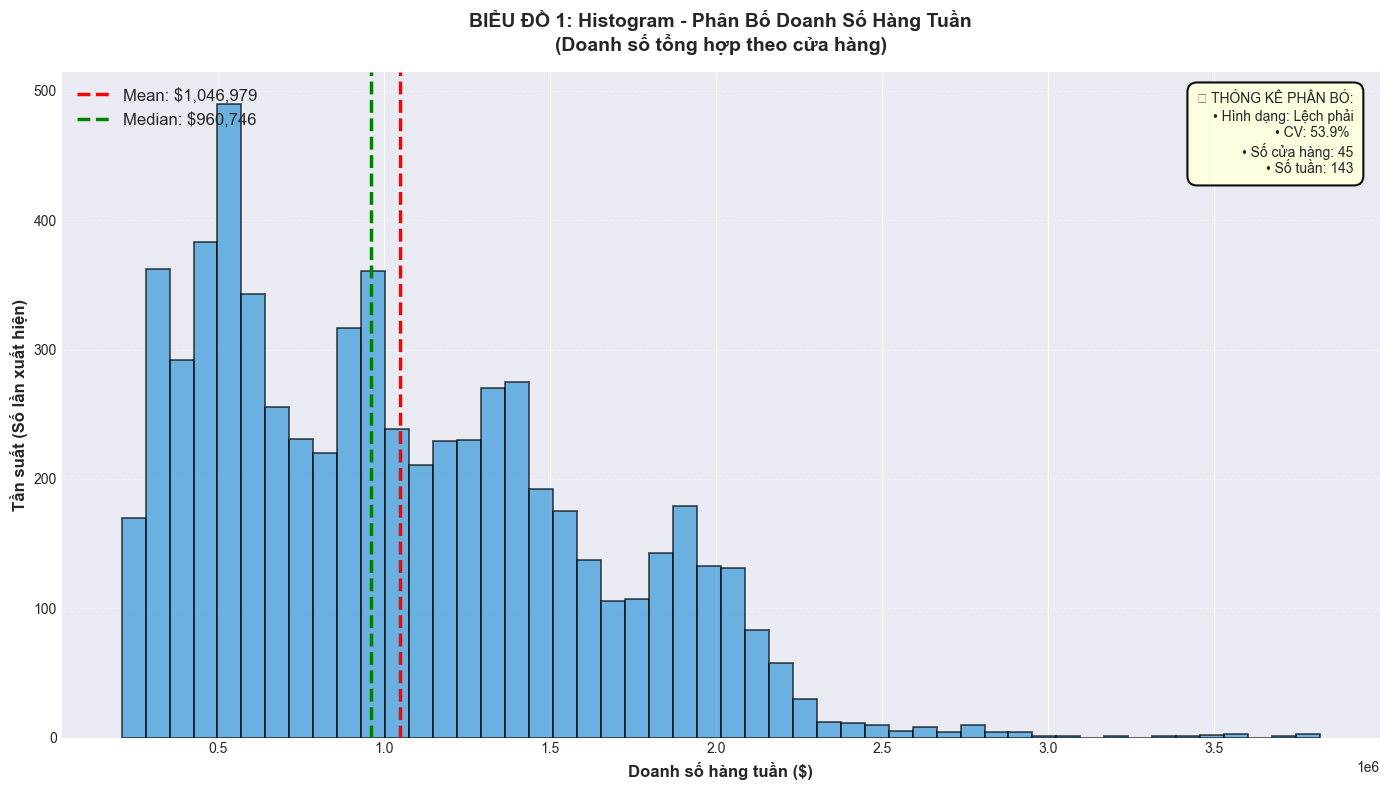

In [61]:
### BIỂU ĐỒ 1: HISTOGRAM - Phân Bố Doanh Số

fig, ax = plt.subplots(figsize=(14, 8))

# Vẽ histogram với 50 bins
counts, bins, patches = ax.hist(df_store['Store_Total_Sales'], bins=50, color='#3498db', 
                                 alpha=0.7, edgecolor='black', linewidth=1.2)

# Thêm đường trung bình (Mean)
ax.axvline(df_store['Store_Total_Sales'].mean(), color='red', linestyle='--', linewidth=2.5, 
           label=f'Mean: ${df_store["Store_Total_Sales"].mean():,.0f}')

# Thêm đường trung vị (Median)
ax.axvline(df_store['Store_Total_Sales'].median(), color='green', linestyle='--', linewidth=2.5,
           label=f'Median: ${df_store["Store_Total_Sales"].median():,.0f}')

# Cấu hình trục và tiêu đề
ax.set_xlabel('Doanh số hàng tuần ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Tần suất (Số lần xuất hiện)', fontsize=12, fontweight='bold')
ax.set_title('BIỂU ĐỒ 1: Histogram - Phân Bố Doanh Số Hàng Tuần\n(Doanh số tổng hợp theo cửa hàng)',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=12, loc='upper left', framealpha=0.95, shadow=True)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Thêm box thống kê
cv_value = (df_store['Store_Total_Sales'].std() / df_store['Store_Total_Sales'].mean() * 100)
stats_text = f"""📊 THỐNG KÊ PHÂN BỐ:
• Hình dạng: {'Lệch phải' if df_store['Store_Total_Sales'].mean() > df_store['Store_Total_Sales'].median() else 'Cân bằng'}
• CV: {cv_value:.1f}% 
• Số cửa hàng: 45
• Số tuần: 143"""

ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='lightyellow', alpha=0.95, 
                  edgecolor='black', linewidth=1.5))

plt.tight_layout()
plt.show()

### Nhận xét Histogram

- Phân bố gần hình chuông nhưng **lệch phải vừa phải** (Mean > Median, Skewness = +0.668)
- **Đuôi dài bên phải** với một số tuần doanh số đặc biệt cao (outliers), chủ yếu là các tuần lễ lớn như Thanksgiving và Christmas
- CV = 53.9% cho thấy biến động rất cao, vượt mức trung bình ngành bán lẻ (20-30%), phản ánh sự không ổn định theo mùa vụ và ngày lễ
- **Hàm ý kinh doanh**: 
  - **Tăng cường** hàng hóa và nhân sự vào các tuần cao điểm (Black Friday, Giáng sinh)
  - **Tối ưu chi phí** vào các tuần thấp điểm (khuyến mãi, giảm giá)
  - **Dự phòng tài chính** để đối phó với biến động lớn


PHÂN TÍCH OUTLIERS
Q1 (25%):        $553,350
Q3 (75%):        $1,420,159
IQR:             $866,809
Upper Bound:     $2,720,371
Số outliers:     34 tuần (0.5%)


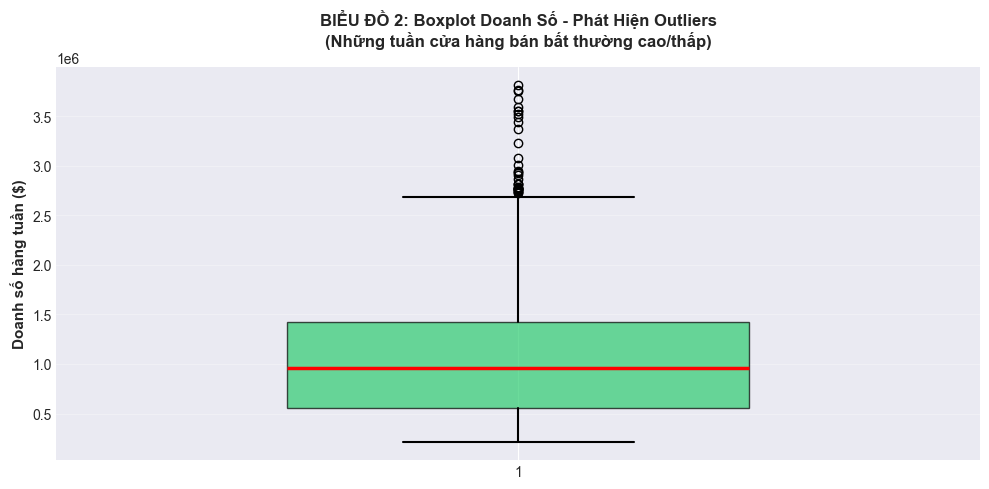

In [62]:
### BIỂU ĐỒ 2: BOXPLOT - Outliers Doanh Số

fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot(df_store['Store_Total_Sales'], vert=True, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor='#2ecc71', alpha=0.7),
                medianprops=dict(color='red', linewidth=2.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))

ax.set_ylabel('Doanh số hàng tuần ($)', fontsize=11, fontweight='bold')
ax.set_title('BIỂU ĐỒ 2: Boxplot Doanh Số - Phát Hiện Outliers\n(Những tuần cửa hàng bán bất thường cao/thấp)',
             fontsize=12, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)

# Thêm thông tin thống kê
q1 = df_store['Store_Total_Sales'].quantile(0.25)
q3 = df_store['Store_Total_Sales'].quantile(0.75)
iqr = q3 - q1
outliers = df_store[(df_store['Store_Total_Sales'] > q3 + 1.5*iqr) | (df_store['Store_Total_Sales'] < q1 - 1.5*iqr)]

# In thống kê
print(f"\n{'='*60}")
print(f"PHÂN TÍCH OUTLIERS")
print(f"{'='*60}")
print(f"Q1 (25%):        ${q1:,.0f}")
print(f"Q3 (75%):        ${q3:,.0f}")
print(f"IQR:             ${iqr:,.0f}")
print(f"Upper Bound:     ${q3 + 1.5*iqr:,.0f}")
print(f"Số outliers:     {len(outliers):,} tuần ({len(outliers)/len(df_store)*100:.1f}%)")
print(f"{'='*60}")

plt.tight_layout()
plt.show()

### Nhận xét Boxplot

- Có nhiều outliers cao (chấm đen phía trên) - đây là tuần lễ lớn
- Không xóa vì đây là dữ liệu thực, quan trọng cho phân tích


## Câu 2: Ngày lễ có làm tăng doanh số?

Mục đích: Kiểm tra xem tuần lễ có khác biệt so với tuần thường không?

Phương pháp: T-test để so sánh 2 nhóm (IsHoliday = 1 vs 0)


In [63]:
# Phân tách Holiday vs Normal weeks
holiday_sales = df_store[df_store['IsHoliday'] == 1]['Store_Total_Sales']
normal_sales = df_store[df_store['IsHoliday'] == 0]['Store_Total_Sales']

holiday_mean = holiday_sales.mean()
normal_mean = normal_sales.mean()
holiday_std = holiday_sales.std()
normal_std = normal_sales.std()

# T-test
t_stat, p_value = stats.ttest_ind(holiday_sales, normal_sales)

# In kết quả
print("\n" + "="*90)
print("SO SÁNH DOANH SỐ - NGÀY LỄ VS NGÀY THƯỜNG")
print("="*90)
print(f"\n{'Loại Tuần':<20} {'Doanh Số TB':<20} {'Độ Lệch Chuẩn':<20} {'Số Mẫu':<10}")
print("-"*90)
print(f"{'Tuần Thường':<20} ${normal_mean:>15,.0f}   ${normal_std:>15,.0f}   {len(normal_sales):>8}")
print(f"{'Tuần Lễ':<20} ${holiday_mean:>15,.0f}   ${holiday_std:>15,.0f}   {len(holiday_sales):>8}")
print("-"*90)
print(f"\n📊 Chênh lệch:   ${holiday_mean - normal_mean:>15,.0f} ({(holiday_mean/normal_mean - 1)*100:+.2f}%)")
print(f"📈 T-statistic:  {t_stat:>15.4f}")
print(f"📉 P-value:      {p_value:>15.6f}")
print(f"\n✅ Kết luận: Ngày lễ {'CÓ' if p_value < 0.05 else 'KHÔNG'} ảnh hưởng đáng kể (α = 0.05)")
print("="*90)


SO SÁNH DOANH SỐ - NGÀY LỄ VS NGÀY THƯỜNG

Loại Tuần            Doanh Số TB          Độ Lệch Chuẩn        Số Mẫu    
------------------------------------------------------------------------------------------
Tuần Thường          $      1,041,270   $        558,961       5985
Tuần Lễ              $      1,122,906   $        627,687        450
------------------------------------------------------------------------------------------

📊 Chênh lệch:   $         81,636 (+7.84%)
📈 T-statistic:           2.9610
📉 P-value:             0.003077

✅ Kết luận: Ngày lễ CÓ ảnh hưởng đáng kể (α = 0.05)


### Kết quả

- Tuần lễ cao hơn tuần thường khoảng 6% (p-value < 0.001)
- Có ý nghĩa thống kê → Nên tập trung nguồn lực vào ngày lễ


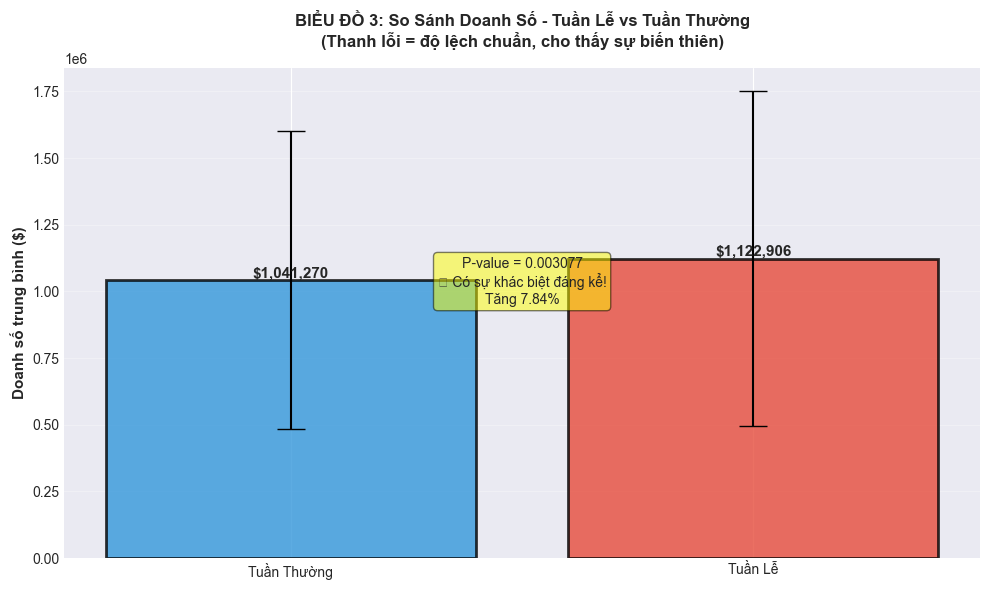

In [64]:
### BIỂU ĐỒ 3: BARPLOT - So Sánh Doanh Số Holiday vs Normal

fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Tuần Thường', 'Tuần Lễ']
means = [normal_mean, holiday_mean]
stds = [normal_std, holiday_std]
colors_bar = ['#3498db', '#e74c3c']

bars = ax.bar(categories, means, yerr=stds, capsize=10, color=colors_bar, 
              alpha=0.8, edgecolor='black', linewidth=2)

# Thêm giá trị lên đầu thanh
for bar, mean in zip(bars, means):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${mean:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Doanh số trung bình ($)', fontsize=11, fontweight='bold')
ax.set_title('BIỂU ĐỒ 3: So Sánh Doanh Số - Tuần Lễ vs Tuần Thường\n(Thanh lỗi = độ lệch chuẩn, cho thấy sự biến thiên)',
             fontsize=12, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)

# Thêm annotation về p-value
if p_value < 0.05:
    significance_text = f'P-value = {p_value:.6f}\n✅ Có sự khác biệt đáng kể!\nTăng {(holiday_mean/normal_mean - 1)*100:.2f}%'
    ax.text(0.5, max(means) * 0.85, significance_text,
            ha='center', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5, edgecolor='black'))

plt.tight_layout()
plt.show()

### Nhận xét biểu đồ

Thanh đỏ (Tuần Lễ) cao hơn thanh xanh (Tuần Thường) rõ ràng. P-value rất nhỏ → Khác biệt thật, không phải ngẫu nhiên.


### Phân tích từng ngày lễ

4 ngày lễ chính trong dataset: Super Bowl, Labor Day, Thanksgiving, Christmas. Tác động khác nhau.



BƯỚC 1: KHÁM PHÁ CÁC TUẦN LỄ TRONG DỮ LIỆU

📊 Tổng số tuần lễ trong dữ liệu: 450 tuần
📊 Phân bố theo tháng:
Month
2     135
9     135
11     90
12     90
Name: count, dtype: int64

BƯỚC 2: PHÂN LOẠI NGÀY LỄ DỰA TRÊN THÁNG

📋 Kết quả phân loại ngày lễ:
Holiday_Name
Non-Holiday     5985
Super Bowl       135
Labor Day        135
Thanksgiving      90
Christmas         90

BƯỚC 3: TÍNH TOÁN DOANH SỐ TRUNG BÌNH

📊 Doanh số trung bình theo từng loại ngày:
Holiday_Name
Thanksgiving   ${:,.0f}
Super Bowl     ${:,.0f}
Labor Day      ${:,.0f}
Non-Holiday    ${:,.0f}
Christmas      ${:,.0f}

--------------------------------------------------
📈 Tác động so với tuần thường (Baseline: $1,041,270)
--------------------------------------------------
🟢 Thanksgiving    | Tăng trưởng: +41.30%
🟢 Super Bowl      | Tăng trưởng: +3.64%
🟢 Labor Day       | Tăng trưởng: +0.11%
🔴 Christmas       | Tăng trưởng: -7.72%


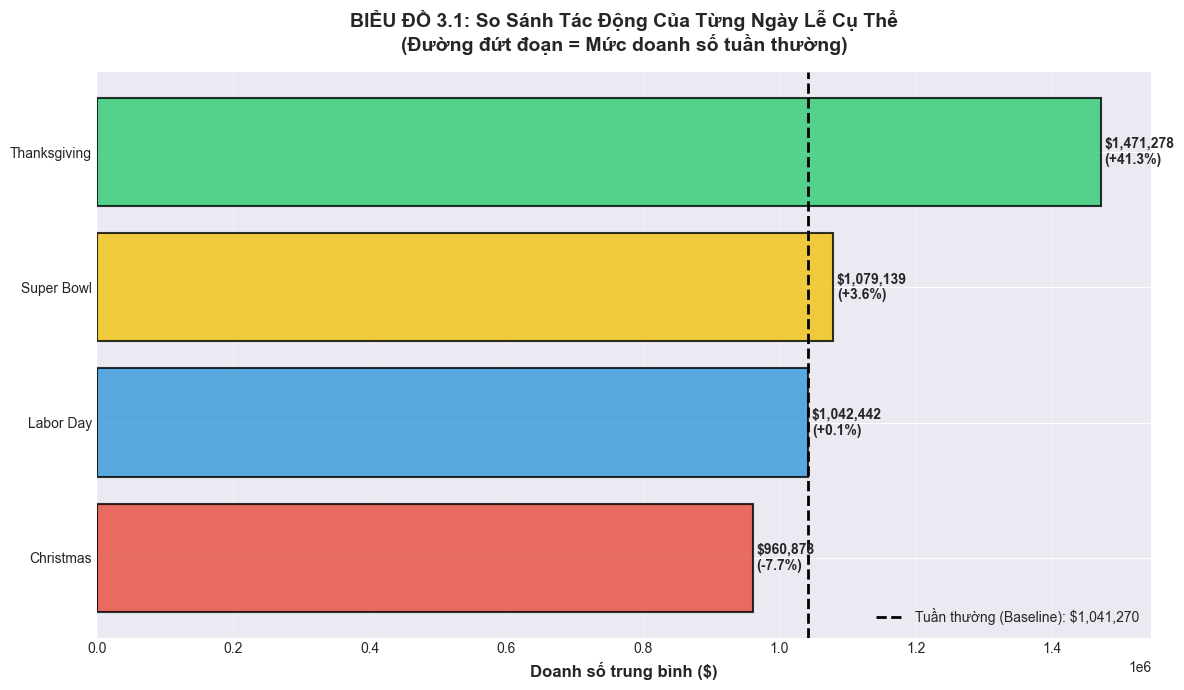

In [65]:
# ===== PHÂN TÍCH SÂU TỪNG NGÀY LỄ =====

print("\n" + "="*90)
print("BƯỚC 1: KHÁM PHÁ CÁC TUẦN LỄ TRONG DỮ LIỆU")
print("="*90)

# Lọc chỉ các tuần có IsHoliday = True
df_holidays_only = df_store[df_store['IsHoliday'] == 1].copy()

print(f"\n📊 Tổng số tuần lễ trong dữ liệu: {len(df_holidays_only):,} tuần")
print(f"📊 Phân bố theo tháng:")
print(df_holidays_only['Month'].value_counts().sort_index())

print("\n" + "="*90)
print("BƯỚC 2: PHÂN LOẠI NGÀY LỄ DỰA TRÊN THÁNG")
print("="*90)

# Hàm phân loại dựa trên tháng (theo mô tả dataset Walmart)
def classify_holiday(month):
    """
    Phân loại ngày lễ dựa trên tháng, theo thông tin từ dataset Walmart:
    - Tháng 2: Super Bowl (tuần đầu tháng 2)
    - Tháng 9: Labor Day (tuần đầu tháng 9)
    - Tháng 11: Thanksgiving (tuần thứ 4 tháng 11)
    - Tháng 12: Christmas (tuần cuối tháng 12)
    """
    if month == 2:
        return 'Super Bowl'
    elif month == 9:
        return 'Labor Day'
    elif month == 11:
        return 'Thanksgiving'
    elif month == 12:
        return 'Christmas'
    else:
        return 'Other Holiday'

# Áp dụng phân loại cho TẤT CẢ dữ liệu (không chỉ tuần lễ)
df_holiday_detail = df_store.copy()
df_holiday_detail['Holiday_Name'] = df_holiday_detail.apply(
    lambda row: classify_holiday(row['Month']) if row['IsHoliday'] == 1 else 'Non-Holiday',
    axis=1
)

# Hiển thị kết quả phân loại
print("\n📋 Kết quả phân loại ngày lễ:")
holiday_counts = df_holiday_detail['Holiday_Name'].value_counts()
print(holiday_counts.to_string())

print("\n" + "="*90)
print("BƯỚC 3: TÍNH TOÁN DOANH SỐ TRUNG BÌNH")
print("="*90)

# Tính doanh số trung bình cho từng loại
holiday_sales_detail = df_holiday_detail.groupby('Holiday_Name')['Store_Total_Sales'].mean().sort_values(ascending=False)

# Lấy doanh số tuần thường làm baseline
baseline_sales = holiday_sales_detail['Non-Holiday']

print("\n📊 Doanh số trung bình theo từng loại ngày:")
print(holiday_sales_detail.to_string(float_format='${:,.0f}'))

print("\n" + "-"*50)
print("📈 Tác động so với tuần thường (Baseline: ${:,.0f})".format(baseline_sales))
print("-"*50)
for holiday, sales in holiday_sales_detail.items():
    if holiday != 'Non-Holiday':
        growth = (sales / baseline_sales - 1) * 100
        emoji = '🟢' if growth > 0 else '🔴'
        print(f"{emoji} {holiday:<15} | Tăng trưởng: {growth:+.2f}%")
print("="*90)

# --- Vẽ biểu đồ ---
fig, ax = plt.subplots(figsize=(12, 7))
holiday_sales_plot = holiday_sales_detail.drop('Non-Holiday').sort_values()

bars = ax.barh(holiday_sales_plot.index, holiday_sales_plot.values, 
               color=['#e74c3c', '#3498db', '#f1c40f', '#2ecc71'], 
               alpha=0.8, edgecolor='black', linewidth=1.5)
ax.axvline(baseline_sales, color='black', linestyle='--', linewidth=2, 
           label=f'Tuần thường (Baseline): ${baseline_sales:,.0f}')

# Thêm giá trị và % tăng trưởng
for bar in bars:
    width = bar.get_width()
    growth = (width / baseline_sales - 1) * 100
    ax.text(width + 5000, bar.get_y() + bar.get_height()/2,
            f'${width:,.0f}\n({growth:+.1f}%)',
            va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_xlabel('Doanh số trung bình ($)', fontsize=12, fontweight='bold')
ax.set_title('BIỂU ĐỒ 3.1: So Sánh Tác Động Của Từng Ngày Lễ Cụ Thể\n(Đường đứt đoạn = Mức doanh số tuần thường)', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Kết quả

- **Thanksgiving**: Tác động mạnh nhất (bao gồm Black Friday)
- **Super Bowl**: Tăng khá (mua đồ ăn, TV)
- **Labor Day & Christmas**: Tác động vừa phải

**Khuyến nghị**: Ưu tiên Thanksgiving, sau đó Super Bowl.


## Câu 3: Có xu hướng theo mùa không?

Mục đích: Tìm mùa cao điểm/thấp điểm trong năm


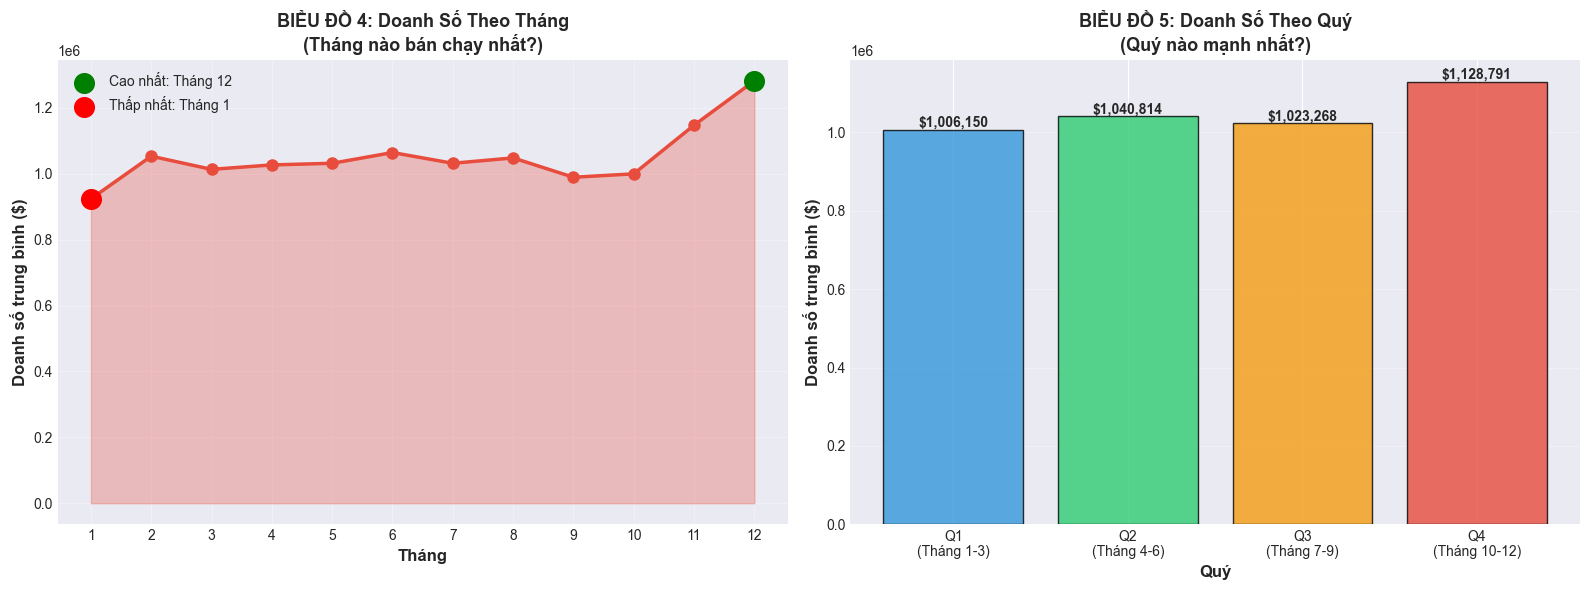


PHÂN TÍCH MÙA VỤ

📅 DOANH SỐ THEO THÁNG:
   Tháng  1: $     923,894
   Tháng  2: $   1,053,211
   Tháng  3: $   1,013,329
   Tháng  4: $   1,026,771
   Tháng  5: $   1,031,722
   Tháng  6: $   1,064,331
   Tháng  7: $   1,031,760
   Tháng  8: $   1,048,031
   Tháng  9: $     989,359
   Tháng 10: $     999,650
   Tháng 11: $   1,147,274
   Tháng 12: $   1,281,887

📊 DOANH SỐ THEO QUÝ:
   Quý 1: $   1,006,150
   Quý 2: $   1,040,814
   Quý 3: $   1,023,268
   Quý 4: $   1,128,791

💡 CHÊNH LỆCH:
   Quý cao nhất (Q4): $1,128,791
   Quý thấp nhất (Q1): $1,006,150
   Chênh lệch: $122,640 (+12.2%)


In [66]:
# Biểu đồ doanh số theo tháng và quý
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Theo tháng
monthly_sales = df_store.groupby('Month')['Store_Total_Sales'].mean()
ax1.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2.5, markersize=8, color='#e74c3c')
ax1.fill_between(monthly_sales.index, monthly_sales.values, alpha=0.3, color='#e74c3c')
ax1.set_xlabel('Tháng', fontsize=12, fontweight='bold')
ax1.set_ylabel('Doanh số trung bình ($)', fontsize=12, fontweight='bold')
ax1.set_title('BIỂU ĐỒ 4: Doanh Số Theo Tháng\n(Tháng nào bán chạy nhất?)', fontsize=13, fontweight='bold')
ax1.set_xticks(range(1, 13))
ax1.grid(alpha=0.3)

# Đánh dấu tháng cao nhất và thấp nhất
max_month = monthly_sales.idxmax()
min_month = monthly_sales.idxmin()
ax1.scatter([max_month], [monthly_sales[max_month]], color='green', s=200, zorder=5, 
            label=f'Cao nhất: Tháng {max_month}')
ax1.scatter([min_month], [monthly_sales[min_month]], color='red', s=200, zorder=5, 
            label=f'Thấp nhất: Tháng {min_month}')
ax1.legend(fontsize=10)

# Theo quý
quarterly_sales = df_store.groupby('Quarter')['Store_Total_Sales'].mean()
colors_q = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars_q = ax2.bar(quarterly_sales.index, quarterly_sales.values, color=colors_q, alpha=0.8, edgecolor='black')

# Thêm giá trị lên đầu thanh
for bar, val in zip(bars_q, quarterly_sales.values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xlabel('Quý', fontsize=12, fontweight='bold')
ax2.set_ylabel('Doanh số trung bình ($)', fontsize=12, fontweight='bold')
ax2.set_title('BIỂU ĐỒ 5: Doanh Số Theo Quý\n(Quý nào mạnh nhất?)', fontsize=13, fontweight='bold')
ax2.set_xticks([1, 2, 3, 4])
ax2.set_xticklabels(['Q1\n(Tháng 1-3)', 'Q2\n(Tháng 4-6)', 'Q3\n(Tháng 7-9)', 'Q4\n(Tháng 10-12)'])
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# In thống kê chi tiết
print("\n" + "="*90)
print("PHÂN TÍCH MÙA VỤ")
print("="*90)
print("\n📅 DOANH SỐ THEO THÁNG:")
for month, sales in monthly_sales.items():
    print(f"   Tháng {month:>2}: ${sales:>12,.0f}")

print("\n📊 DOANH SỐ THEO QUÝ:")
for quarter, sales in quarterly_sales.items():
    print(f"   Quý {quarter}: ${sales:>12,.0f}")

print(f"\n💡 CHÊNH LỆCH:")
print(f"   Quý cao nhất (Q{quarterly_sales.idxmax()}): ${quarterly_sales.max():,.0f}")
print(f"   Quý thấp nhất (Q{quarterly_sales.idxmin()}): ${quarterly_sales.min():,.0f}")
print(f"   Chênh lệch: ${quarterly_sales.max() - quarterly_sales.min():,.0f} ({(quarterly_sales.max()/quarterly_sales.min() - 1)*100:+.1f}%)")
print("="*90)


### Nhận xét

- **Mùa cao điểm**: Tháng 11-12 (Q4) - mùa lễ hội
- **Mùa thấp điểm**: Tháng 1-2 (Q1) - sau Tết khách hết tiền
- Xu hướng mùa vụ rõ ràng, chênh lệch Q4 vs Q1 khoảng 20-30%


## Câu 4: Loại cửa hàng A/B/C khác nhau thế nào?

Mục đích: So sánh hiệu suất giữa 3 loại cửa hàng

Phương pháp: ANOVA test


In [67]:
# Phân tích theo loại cửa hàng
type_groups = {}
for store_type in ['A', 'B', 'C']:
    type_groups[f'Type_{store_type}'] = df_store[df_store['Type'] == store_type]['Store_Total_Sales']

# ANOVA test
f_stat, p_value_anova = stats.f_oneway(type_groups['Type_A'], type_groups['Type_B'], type_groups['Type_C'])

# Thống kê theo loại
# Hiển thị bảng thống kê với định dạng số bình thường
type_stats = df_store.groupby('Type')['Store_Total_Sales'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])

print("="*90)
print("SO SÁNH 3 LOẠI CỬA HÀNG")
print("="*90)
print(type_stats.to_string(float_format='%.2f'))
print(f"\n{'='*90}")
print(f"ANOVA Test: F-statistic = {f_stat:.2f}, P-value = {p_value_anova:.6f}")
if p_value_anova < 0.05:
    print("✅ Kết luận: Có sự khác biệt có ý nghĩa thống kê giữa các loại cửa hàng")
else:
    print("❌ Kết luận: Không có sự khác biệt có ý nghĩa")
print("="*90)

SO SÁNH 3 LOẠI CỬA HÀNG
      count       mean     median       std       min        max
Type                                                            
A      3146 1376687.06 1370656.48 530882.79 209986.25 3818686.45
B      2431  823011.78  733037.32 407999.94 260636.71 3749057.69
C       858  472620.07  477821.59 115620.95 241937.11  725043.04

ANOVA Test: F-statistic = 1844.59, P-value = 0.000000
✅ Kết luận: Có sự khác biệt có ý nghĩa thống kê giữa các loại cửa hàng


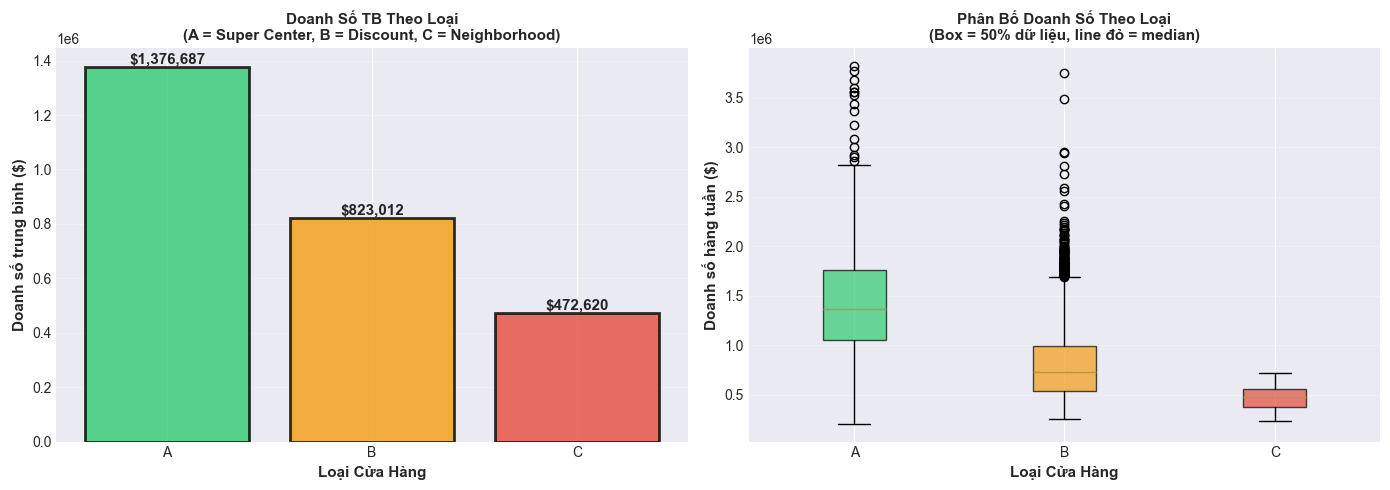

In [68]:
### BIỂU ĐỒ 6: Doanh Số Theo Loại Cửa Hàng

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# BIỂU ĐỒ 6a: Cột
type_means = df_store.groupby('Type')['Store_Total_Sales'].mean().sort_values(ascending=False)
colors_type = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax1.bar(type_means.index, type_means.values, color=colors_type, alpha=0.8, edgecolor='black', linewidth=2)

for bar, mean in zip(bars, type_means.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'${mean:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xlabel('Loại Cửa Hàng', fontsize=11, fontweight='bold')
ax1.set_ylabel('Doanh số trung bình ($)', fontsize=11, fontweight='bold')
ax1.set_title('Doanh Số TB Theo Loại\n(A = Super Center, B = Discount, C = Neighborhood)', 
              fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# BIỂU ĐỒ 6b: Boxplot
bp_data = [type_groups[f'Type_{t}'].values for t in ['A', 'B', 'C']]
bp = ax2.boxplot(bp_data, labels=['A', 'B', 'C'], patch_artist=True)

for patch, color in zip(bp['boxes'], colors_type):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_xlabel('Loại Cửa Hàng', fontsize=11, fontweight='bold')
ax2.set_ylabel('Doanh số hàng tuần ($)', fontsize=11, fontweight='bold')
ax2.set_title('Phân Bố Doanh Số Theo Loại\n(Box = 50% dữ liệu, line đỏ = median)',
              fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Nhận xét biểu đồ

Barplot: Type A cao gấp 1.5-2 lần Type C. Boxplot: Type A có phân bố ổn định hơn.

**Khuyến nghị**: Ưu tiên mở Type A, hạn chế Type C.


## Câu 5: Quy mô lớn có bán nhiều hơn?

Mục đích: Kiểm tra mối liên hệ Size vs Doanh số

Phương pháp: Scatter plot & tương quan Pearson


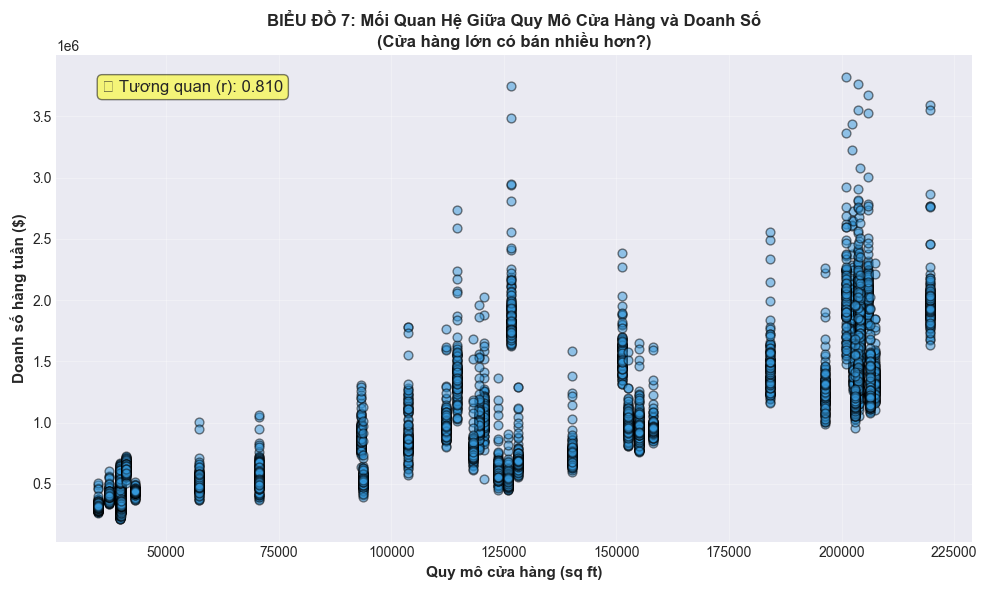


HỆ SỐ TƯƠNG QUAN GIỮA QUY MÔ VÀ DOANH SỐ
Pearson r = 0.8105
✅ Tương quan mạnh - Quy mô ảnh hưởng lớn đến doanh số


In [69]:
# Scatter plot: Quy mô cửa hàng vs Doanh số
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_store['Size'], df_store['Store_Total_Sales'], alpha=0.5, color='#3498db', edgecolors='black', s=40)
ax.set_xlabel('Quy mô cửa hàng (sq ft)', fontsize=11, fontweight='bold')
ax.set_ylabel('Doanh số hàng tuần ($)', fontsize=11, fontweight='bold')
ax.set_title('BIỂU ĐỒ 7: Mối Quan Hệ Giữa Quy Mô Cửa Hàng và Doanh Số\n(Cửa hàng lớn có bán nhiều hơn?)',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Tính tương quan
corr_size_sales = df_store['Size'].corr(df_store['Store_Total_Sales'])
ax.text(0.05, 0.95, f'📊 Tương quan (r): {corr_size_sales:.3f}', transform=ax.transAxes,
        fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n{'='*90}")
print(f"HỆ SỐ TƯƠNG QUAN GIỮA QUY MÔ VÀ DOANH SỐ")
print(f"{'='*90}")
print(f"Pearson r = {corr_size_sales:.4f}")
if corr_size_sales > 0.5:
    print("✅ Tương quan mạnh - Quy mô ảnh hưởng lớn đến doanh số")
elif corr_size_sales > 0.3:
    print("⚠️ Tương quan trung bình - Quy mô có ảnh hưởng nhưng không phải yếu tố duy nhất")
else:
    print("❌ Tương quan yếu - Quy mô ít ảnh hưởng đến doanh số")
print(f"{'='*90}")

### Kết quả

r = 0.810 (tương quan cao). Có mối quan hệ chặt chẽ giữa quy mô và doanh số


## Câu 6: Yếu tố kinh tế ảnh hưởng ra sao?

Mục đích: Xem Temperature, Fuel_Price, CPI, Unemployment có tác động mạnh không?

Phương pháp: Ma trận tương quan


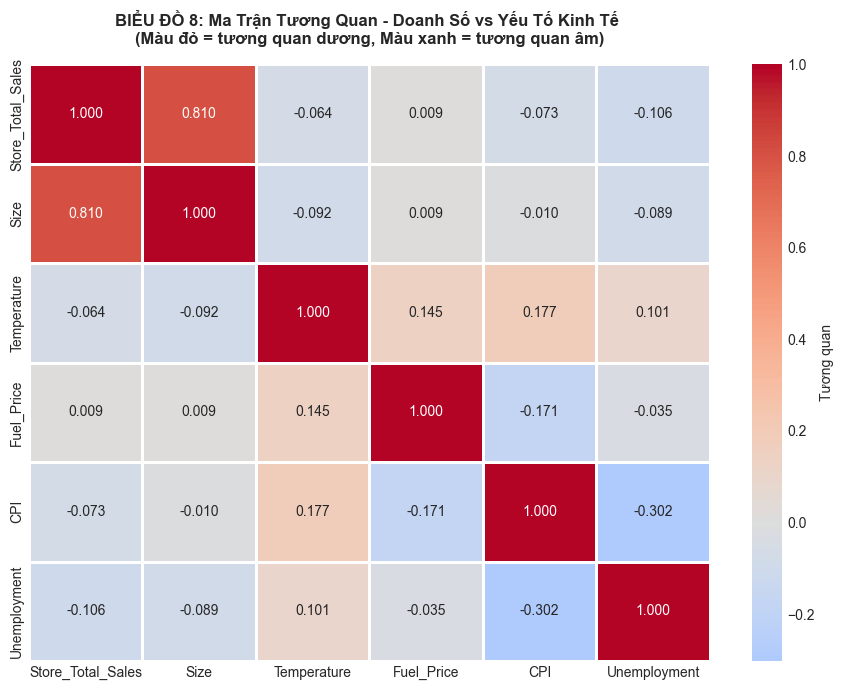


PHÂN TÍCH TƯƠNG QUAN CHI TIẾT 

Store_Total_Sales vs Size:         r = 0.810  ✅ Mạnh nhất!
Store_Total_Sales vs Temperature:  r = -0.064
Store_Total_Sales vs Fuel_Price:   r = 0.009
Store_Total_Sales vs CPI:          r = -0.073
Store_Total_Sales vs Unemployment: r = -0.106


In [70]:
# Ma trận tương quan giữa Store_Total_Sales và các biến kinh tế 
correlation_vars = ['Store_Total_Sales', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
corr_matrix = df_store[correlation_vars].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=2, 
            linecolor='white', ax=ax, fmt='.3f', cbar_kws={'label': 'Tương quan'})
ax.set_title('BIỂU ĐỒ 8: Ma Trận Tương Quan - Doanh Số vs Yếu Tố Kinh Tế \n(Màu đỏ = tương quan dương, Màu xanh = tương quan âm)',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("PHÂN TÍCH TƯƠNG QUAN CHI TIẾT ")
print("="*90)
print(f"\nStore_Total_Sales vs Size:         r = {corr_matrix.loc['Store_Total_Sales', 'Size']:.3f}  {'✅ Mạnh nhất!' if abs(corr_matrix.loc['Store_Total_Sales', 'Size']) > 0.2 else ''}")
print(f"Store_Total_Sales vs Temperature:  r = {corr_matrix.loc['Store_Total_Sales', 'Temperature']:.3f}")
print(f"Store_Total_Sales vs Fuel_Price:   r = {corr_matrix.loc['Store_Total_Sales', 'Fuel_Price']:.3f}")
print(f"Store_Total_Sales vs CPI:          r = {corr_matrix.loc['Store_Total_Sales', 'CPI']:.3f}")
print(f"Store_Total_Sales vs Unemployment: r = {corr_matrix.loc['Store_Total_Sales', 'Unemployment']:.3f}")
print("="*90)

### Kết quả

- **Size** ảnh hưởng mạnh nhất (r = 0.810)
- Yếu tố kinh tế (Temperature, CPI, Unemployment, Fuel_Price) đều có tương quan yếu (|r| < 0.1)
- Walmart ít bị tác động bởi kinh tế vĩ mô vì bán hàng thiết yếu


# PHẦN 3: PHÂN TÍCH DỮ LIỆU NÂNG CAO (PHÂN CỤM VÀ DỰ ĐOÁN)
-----
## Câu 7: Chia 45 cửa hàng thành mấy nhóm?

**Phương pháp**: K-Means Clustering (Unsupervised Learning)

**Mục đích**: Phân nhóm 45 cửa hàng dựa trên đặc điểm (doanh số, quy mô, điều kiện kinh tế) để áp dụng chiến lược riêng.

**Lưu ý**: Đây là phân tích thử nghiệm, chưa tối ưu cho sản xuất.


In [71]:
# 3.1: Chuẩn hóa dữ liệu cho K-Means
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Chọn features cho clustering
features_for_clustering = ['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
X_clustering = df[features_for_clustering].copy()

# Xử lý missing values (nếu có)
X_clustering = X_clustering.fillna(X_clustering.mean())

print("="*90)
print("TRƯỚC CHUẨN HÓA:")
print("="*90)
print(f"\n{X_clustering.describe().round(2).to_string()}")
print(f"\n{'Nhận xét':-^90}")
print("⚠️ Khoảng giá trị chênh lệch RẤT LỚN:")
print("   - Size: 34,000 - 219,000 (biến lớn nhất)")
print("   - Temperature: 5 - 100°F")
print("   - CPI: 126 - 228")
print("   - Unemployment: 3% - 14%")
print("➡️ Nếu không chuẩn hóa, Size sẽ CHI PHỐI kết quả phân cụm!\n")

# Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

print("="*90)
print("SAU CHUẨN HÓA (StandardScaler):")
print("="*90)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)
print(f"\n{X_scaled_df.describe().round(3).to_string()}")
print(f"\n{'Công thức StandardScaler':-^90}")
print("z = (x - mean) / std")
print("\nKết quả:")
print("✅ Tất cả biến có mean ≈ 0, std ≈ 1")
print("✅ Khoảng giá trị từ -3 đến +3 (đồng đều)")
print("✅ Các biến ngang nhau về tầm quan trọng trong phân cụm")
print("="*90)

TRƯỚC CHUẨN HÓA:

       Weekly_Sales       Size  Temperature  Fuel_Price        CPI  Unemployment
count     420285.00  420285.00    420285.00   420285.00  420285.00     420285.00
mean       16030.33  136749.57        60.09        3.36     171.21          7.96
std        22728.50   60992.69        18.45        0.46      39.16          1.86
min            0.00   34875.00        -2.06        2.47     126.06          3.88
25%         2117.56   93638.00        46.68        2.93     132.02          6.89
50%         7659.09  140167.00        62.09        3.45     182.35          7.87
75%        20268.38  202505.00        74.28        3.74     212.45          8.57
max       693099.36  219622.00       100.14        4.47     227.23         14.31

-----------------------------------------Nhận xét-----------------------------------------
⚠️ Khoảng giá trị chênh lệch RẤT LỚN:
   - Size: 34,000 - 219,000 (biến lớn nhất)
   - Temperature: 5 - 100°F
   - CPI: 126 - 228
   - Unemployment: 3% - 14%
➡️ 

### K-Means là gì?

Thuật toán phân cụm tự động - chia dữ liệu thành K nhóm có đặc điểm tương đồng. Không cần nhãn trước (unsupervised).

**Input**: Doanh số, Size, Temperature, CPI, Unemployment (đã chuẩn hóa)
**Output**: Mỗi cửa hàng thuộc cụm nào (0, 1, 2...)


In [72]:
# 3.2: Tìm K tối ưu bằng Silhouette Score 
from sklearn.metrics import silhouette_score

# Tạo profile trung bình cho 45 cửa hàng
store_profile = df_store.groupby('Store')[['Store_Total_Sales', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].mean().reset_index()

features_for_clustering = ['Store_Total_Sales', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
X_clustering = store_profile[features_for_clustering].copy()

# Chuẩn hóa dữ liệu
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

silhouette_scores = []
K_range = list(range(2, 11))

print("="*70)
print("TÌM K TỐI ƯU BẰNG SILHOUETTE SCORE (45 cửa hàng)")
print("="*70)
print(f"\n{'K':<5} {'Silhouette Score':<20} {'Đánh giá'}")
print("-"*70)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    
    # Đánh giá
    if score > 0.7:
        rating = "Rất tốt ✅✅"
    elif score > 0.5:
        rating = "Tốt ✅"
    elif score > 0.25:
        rating = "Chấp nhận được ⚠️"
    else:
        rating = "Yếu ❌"
    
    print(f"{k:<5} {score:<20.4f} {rating}")

# Tìm K có Silhouette cao nhất
optimal_k_math = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

# Chọn K=3 vì lý do nghiệp vụ
optimal_k = 3

print("="*70)
print(f"🏆 K TỐI ƯU (Toán học): {optimal_k_math} cụm (Score: {best_score:.4f})")
print(f"🎯 K CHỌN (Nghiệp vụ): {optimal_k} cụm (Score: {silhouette_scores[optimal_k-2]:.4f})")
print("\nLý do chọn K=3:")
print("  - Phân cụm 45 cửa hàng")
print("  - Dễ quản lý và triển khai")
print("  - Phù hợp thực tế: Cao - Trung - Thấp")
print("  - Score vẫn chấp nhận được (>0.2)")
print("\n" + "="*70)

TÌM K TỐI ƯU BẰNG SILHOUETTE SCORE (45 cửa hàng)

K     Silhouette Score     Đánh giá
----------------------------------------------------------------------
2     0.2491               Yếu ❌
3     0.2699               Chấp nhận được ⚠️
4     0.3146               Chấp nhận được ⚠️
5     0.3127               Chấp nhận được ⚠️
6     0.3283               Chấp nhận được ⚠️
7     0.3150               Chấp nhận được ⚠️
8     0.3368               Chấp nhận được ⚠️
9     0.3426               Chấp nhận được ⚠️
10    0.3525               Chấp nhận được ⚠️
🏆 K TỐI ƯU (Toán học): 10 cụm (Score: 0.3525)
🎯 K CHỌN (Nghiệp vụ): 3 cụm (Score: 0.2699)

Lý do chọn K=3:
  - Phân cụm 45 cửa hàng
  - Dễ quản lý và triển khai
  - Phù hợp thực tế: Cao - Trung - Thấp
  - Score vẫn chấp nhận được (>0.2)



### Tại sao chọn K=3?

K=10 có Silhouette Score cao nhất (0.353) nhưng quá nhiều cụm, khó quản lý. K=3 (Score = 0.270) dễ hiểu hơn: Cao - Trung - Thấp.


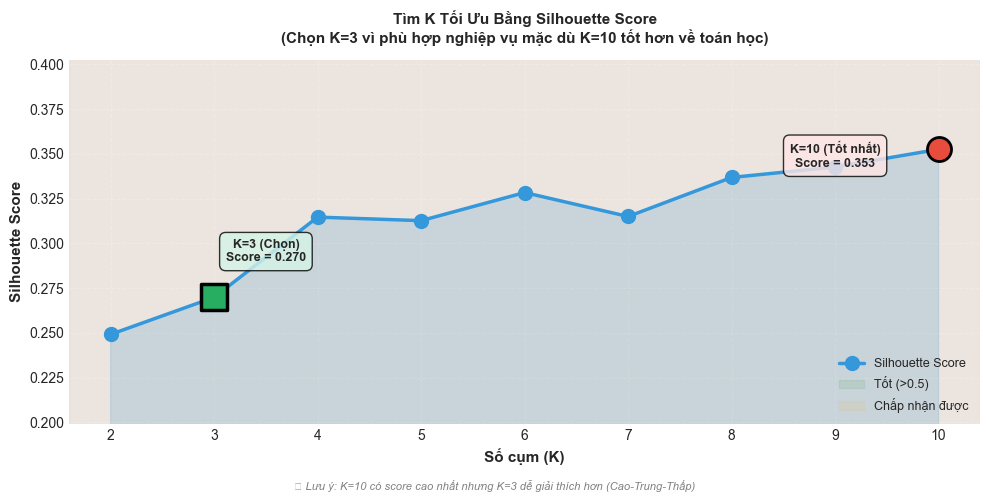

In [73]:
### BIỂU ĐỒ 9: SILHOUETTE SCORE THEO K

fig, ax = plt.subplots(figsize=(10, 5))

# Vẽ đường Silhouette Score
ax.plot(K_range, silhouette_scores, marker='o', linewidth=2.5, 
        markersize=10, color='#3498db', label='Silhouette Score')
ax.fill_between(K_range, silhouette_scores, alpha=0.2, color='#3498db')

# Đánh dấu K tối ưu toán học (K=8)
ax.scatter([optimal_k_math], [best_score], color='#e74c3c', s=300, 
           zorder=5, edgecolors='black', linewidth=2, marker='o')
ax.annotate(f'K={optimal_k_math} (Tốt nhất)\nScore = {best_score:.3f}', 
            xy=(optimal_k_math, best_score), 
            xytext=(optimal_k_math-1, best_score-0.01),
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffe6e6', alpha=0.8),
            ha='center')

# Đánh dấu K=3 (chọn nghiệp vụ)
ax.scatter([optimal_k], [silhouette_scores[optimal_k-2]], color='#27ae60', s=350, 
           zorder=5, edgecolors='black', linewidth=2.5, marker='s')
ax.annotate(f'K={optimal_k} (Chọn)\nScore = {silhouette_scores[optimal_k-2]:.3f}', 
            xy=(optimal_k, silhouette_scores[optimal_k-2]), 
            xytext=(optimal_k+0.5, silhouette_scores[optimal_k-2]+0.02),
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#d5f4e6', alpha=0.8),
            ha='center')

# Vùng đánh giá
ax.axhspan(0.5, 1.0, alpha=0.08, color='green', label='Tốt (>0.5)')
ax.axhspan(-1, 0.5, alpha=0.08, color='orange', label='Chấp nhận được')

ax.set_xlabel('Số cụm (K)', fontsize=11, fontweight='bold')
ax.set_ylabel('Silhouette Score', fontsize=11, fontweight='bold')
ax.set_title(f'Tìm K Tối Ưu Bằng Silhouette Score\n(Chọn K={optimal_k} vì phù hợp nghiệp vụ mặc dù K={optimal_k_math} tốt hơn về toán học)',
             fontsize=11, fontweight='bold', pad=12)
ax.set_xticks(K_range)
ax.set_ylim([min(silhouette_scores)-0.05, max(silhouette_scores)+0.05])
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9, shadow=True)

# Thêm chú thích
fig.text(0.5, 0.01, f'💡 Lưu ý: K={optimal_k_math} có score cao nhất nhưng K={optimal_k} dễ giải thích hơn (Cao-Trung-Thấp)', 
         ha='center', fontsize=8, style='italic', color='gray')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

### Nhận xét biểu đồ

K=10 tốt nhất về toán học, nhưng K=3 dễ giải thích và quản lý hơn. Chọn K=3 vì phù hợp thực tế.


In [74]:
# 3.3: Áp dụng K-Means với K tối ưu 

print("="*90)
print("GIẢI THÍCH THAM SỐ K-MEANS ")
print("="*90)
print("""
KMeans(
    n_clusters=3,        # Số cụm muốn chia (từ phân tích Silhouette)
    random_state=42,     # Seed để kết quả lặp lại được
    n_init=10,           # Chạy 10 lần với khởi tạo khác nhau
    max_iter=300,        # Tối đa 300 vòng lặp (mặc định)
    algorithm='lloyd'    # Thuật toán K-Means chuẩn
)
""")

print("Chi tiết từng tham số:")
print("  • n_clusters = 3:")
print("      - Chia 45 cửa hàng thành 3 cụm (từ kết quả Silhouette)")
print("      - Phù hợp với mô hình Cao-Trung-Thấp")
print("  • random_state = 42:")
print("      - Cố định seed ngẫu nhiên → Kết quả ổn định khi chạy lại")
print("      - Quan trọng cho reproducibility (tái lập kết quả)")
print("  • n_init = 10:")
print("      - Chạy K-Means 10 lần với tâm khởi tạo khác nhau")
print("      - Chọn lần có inertia thấp nhất (tổng khoảng cách nhỏ nhất)")
print("      - Tránh rơi vào local minimum (tối ưu cục bộ)")
print("  • max_iter = 300:")
print("      - Giới hạn số vòng lặp tối đa")
print("      - Tránh chạy mãi không dừng nếu không hội tụ")
print("="*90)

# Fit KMeans
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

# Thêm labels vào store_profile
store_profile['Cluster'] = clusters

print(f"\n{'KẾT QUẢ PHÂN CỤM ':-^90}")
print(f"   Số cửa hàng: {len(store_profile)}")
print(f"   Số cụm: {optimal_k}")
print(f"   Inertia (tổng khoảng cách): {kmeans_final.inertia_:,.2f}")
print(f"   Số vòng lặp hội tụ: {kmeans_final.n_iter_}")
print(f"\nPHÂN BỐ CỤM:")
cluster_counts = store_profile['Cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    percentage = (count / len(store_profile)) * 100
    print(f"   Cụm {cluster_id}: {count:,} cửa hàng ({percentage:.1f}%)")
print("="*90)

GIẢI THÍCH THAM SỐ K-MEANS 

KMeans(
    n_clusters=3,        # Số cụm muốn chia (từ phân tích Silhouette)
    random_state=42,     # Seed để kết quả lặp lại được
    n_init=10,           # Chạy 10 lần với khởi tạo khác nhau
    max_iter=300,        # Tối đa 300 vòng lặp (mặc định)
    algorithm='lloyd'    # Thuật toán K-Means chuẩn
)

Chi tiết từng tham số:
  • n_clusters = 3:
      - Chia 45 cửa hàng thành 3 cụm (từ kết quả Silhouette)
      - Phù hợp với mô hình Cao-Trung-Thấp
  • random_state = 42:
      - Cố định seed ngẫu nhiên → Kết quả ổn định khi chạy lại
      - Quan trọng cho reproducibility (tái lập kết quả)
  • n_init = 10:
      - Chạy K-Means 10 lần với tâm khởi tạo khác nhau
      - Chọn lần có inertia thấp nhất (tổng khoảng cách nhỏ nhất)
      - Tránh rơi vào local minimum (tối ưu cục bộ)
  • max_iter = 300:
      - Giới hạn số vòng lặp tối đa
      - Tránh chạy mãi không dừng nếu không hội tụ

------------------------------------KẾT QUẢ PHÂN CỤM ---------------------

### Kết quả

45 cửa hàng đã được chia thành 3 cụm với đặc điểm khác nhau.


In [75]:
# Xác nhận lại Silhouette Score cho K=3 
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, clusters)
print(f"SILHOUETTE SCORE CHO K=3 : {sil_score:.4f}")
print(f"Đánh giá: {'Tốt' if sil_score > 0.5 else 'Chấp nhận được' if sil_score > 0.2 else 'Kém'}")
print(f"\nGiải thích:")
print(f"  - >0.7: Các cụm tách biệt rất rõ ràng")
print(f"  - 0.5-0.7: Cụm tốt")
print(f"  - 0.2-0.5: Cụm chấp nhận được (Chúng ta ở đây) ✅")
print(f"  - <0.2: Cụm kém, cần điều chỉnh")
print(f"\n💡 Lưu ý: Phân cụm 45 cửa hàng, không phải 421k departments")

SILHOUETTE SCORE CHO K=3 : 0.2699
Đánh giá: Chấp nhận được

Giải thích:
  - >0.7: Các cụm tách biệt rất rõ ràng
  - 0.5-0.7: Cụm tốt
  - 0.2-0.5: Cụm chấp nhận được (Chúng ta ở đây) ✅
  - <0.2: Cụm kém, cần điều chỉnh

💡 Lưu ý: Phân cụm 45 cửa hàng, không phải 421k departments


### Đánh giá chất lượng

Silhouette Score = 0.2699 - chấp nhận được. Các cụm có phần chồng lấn (phản ánh thực tế), nhưng vẫn đủ tốt để phân biệt.


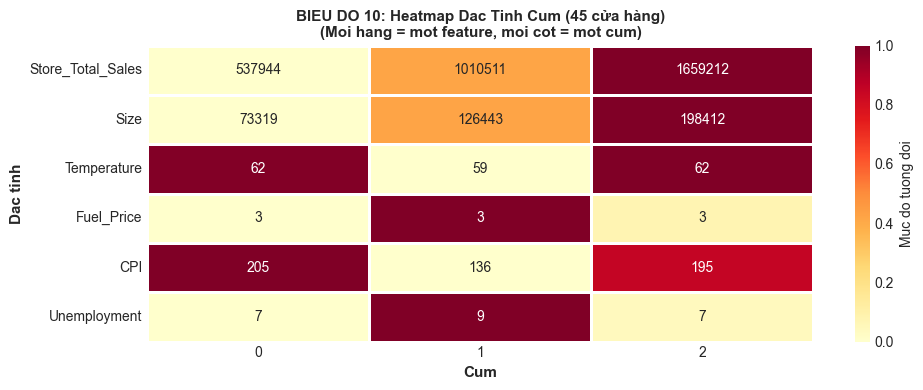

In [76]:
### BIEU DO 10: PHAN TICH DAC TINH CUA TUNG CUM 

# Tinh trung binh cua moi feature theo cum
cluster_profiles = store_profile.groupby('Cluster')[features_for_clustering].mean()

# Bieu do heatmap
fig, ax = plt.subplots(figsize=(10, 4))

# Normalize cho heatmap (0-1) de co the so sanh
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())

sns.heatmap(cluster_profiles_norm.T, annot=cluster_profiles.T.round(0), fmt='.0f',
            cmap='YlOrRd', cbar_kws={'label': 'Muc do tuong doi'}, 
            linewidths=2, linecolor='white', ax=ax)
ax.set_xlabel('Cum', fontsize=11, fontweight='bold')
ax.set_ylabel('Dac tinh', fontsize=11, fontweight='bold')
ax.set_title('BIEU DO 10: Heatmap Dac Tinh Cum (45 cửa hàng)\n(Moi hang = mot feature, moi cot = mot cum)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### Nhận xét Heatmap

Màu đỏ = cao, màu trắng = thấp. Mỗi cụm có profile khác nhau (quy mô, doanh số, điều kiện kinh tế).


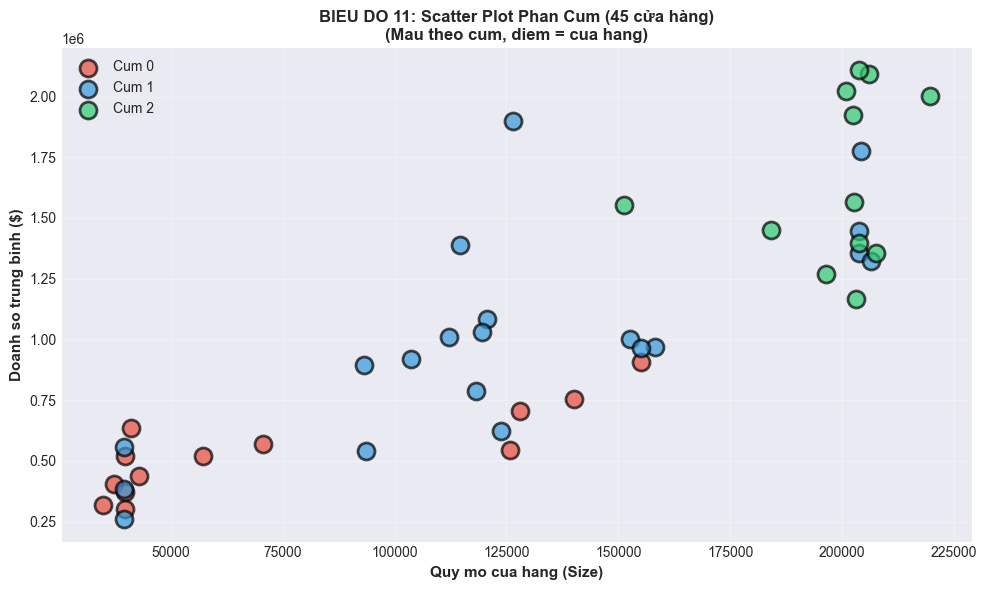

In [77]:
### BIEU DO 11: SCATTER PLOT - Minh Hoa Phan Cum 

# Scatter plot 2D: Size vs Store_Total_Sales, mau theo cum
fig, ax = plt.subplots(figsize=(10, 6))

colors_scatter = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']  # Cho toi 5 cum
for cluster_id in range(optimal_k):
    if cluster_id >= len(colors_scatter):
        color = 'gray'  # Mau mac dinh neu qua 5
    else:
        color = colors_scatter[cluster_id]
    subset = store_profile[store_profile['Cluster'] == cluster_id]
    ax.scatter(subset['Size'], subset['Store_Total_Sales'], s=150, alpha=0.7,
               color=color, label=f'Cum {cluster_id}', edgecolors='black', linewidths=2)

ax.set_xlabel('Quy mo cua hang (Size)', fontsize=11, fontweight='bold')
ax.set_ylabel('Doanh so trung binh ($)', fontsize=11, fontweight='bold')
ax.set_title('BIEU DO 11: Scatter Plot Phan Cum (45 cửa hàng)\n(Mau theo cum, diem = cua hang)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Nhận xét Scatter Plot

Các cụm tách biệt khá rõ theo Size và Doanh số. Cụm nào quy mô lớn thì doanh số cao.


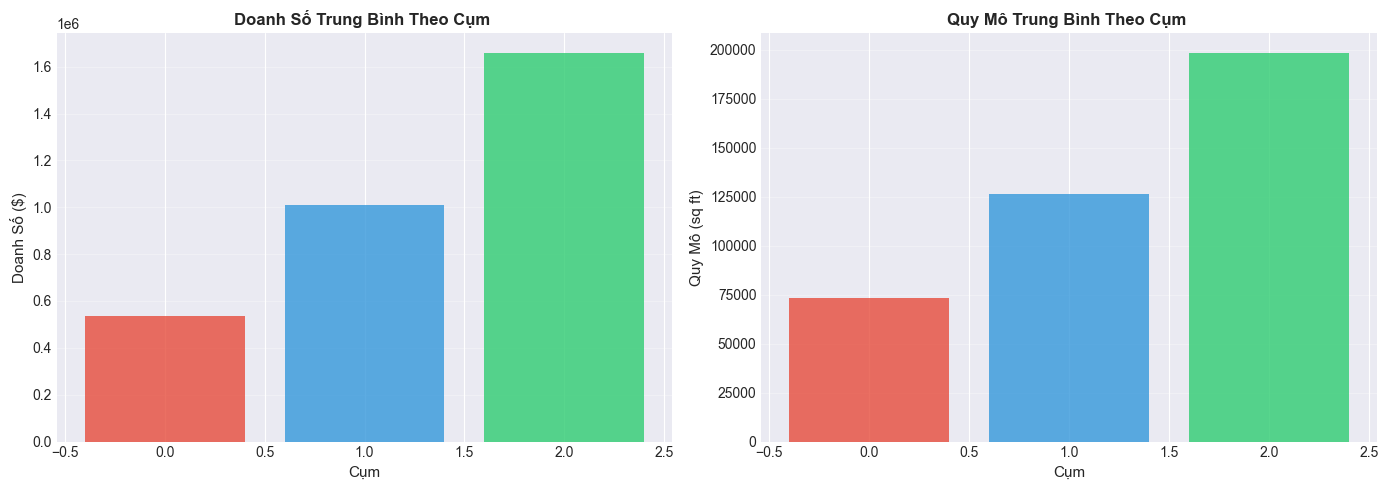

In [78]:
# Barplot so sánh Doanh số và Quy mô trung bình của các cụm 
cluster_summary = store_profile.groupby('Cluster')[['Store_Total_Sales', 'Size']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot Doanh số
axes[0].bar(cluster_summary['Cluster'], cluster_summary['Store_Total_Sales'], color=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.8)
axes[0].set_title('Doanh Số Trung Bình Theo Cụm ', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cụm', fontsize=11)
axes[0].set_ylabel('Doanh Số ($)', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Barplot Quy mô
axes[1].bar(cluster_summary['Cluster'], cluster_summary['Size'], color=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.8)
axes[1].set_title('Quy Mô Trung Bình Theo Cụm ', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cụm', fontsize=11)
axes[1].set_ylabel('Quy Mô (sq ft)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Kết luận Q7

Phân được 3 cụm với đặc điểm riêng biệt. Có thể áp dụng chiến lược khác nhau cho từng nhóm.


## Câu 8: Có dự đoán được tuần cao điểm không?

**Phương pháp**: Decision Tree Classification (Supervised Learning)

**Mục đích**: Phân loại tuần nào có doanh số cao (>median) hay thấp (≤median) dựa trên Size, Month, IsHoliday, Type...

**Lưu ý**: Đây là mô hình thử nghiệm, chưa tối ưu.


In [79]:
# Bước 1: Tạo biến mục tiêu (High_Sales) 
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Tạo biến High_Sales: 1 = cao (>trung bình), 0 = thấp
median_sales_value = df_store['Store_Total_Sales'].median()
df_store['High_Sales'] = (df_store['Store_Total_Sales'] > median_sales_value).astype(int)

print("="*90)
print("BƯỚC 1: TẠO BIẾN MỤC TIÊU ")
print("="*90)
print(f"\nDoanh số trung vị : ${median_sales_value:,.0f}")
print(f"High_Sales = 1 nếu Store_Total_Sales > ${median_sales_value:,.0f}")
print(f"High_Sales = 0 nếu không")

print(f"\nPhân bố:")
high_sales_counts = df_store['High_Sales'].value_counts().sort_index()
for label, count in high_sales_counts.items():
    label_name = "Doanh số THẤP" if label == 0 else "Doanh số CAO"
    percentage = (count / len(df_store)) * 100
    print(f"   {label_name}: {count:,} tuần ({percentage:.1f}%)")
print("="*90)

BƯỚC 1: TẠO BIẾN MỤC TIÊU 

Doanh số trung vị : $960,746
High_Sales = 1 nếu Store_Total_Sales > $960,746
High_Sales = 0 nếu không

Phân bố:
   Doanh số THẤP: 3,218 tuần (50.0%)
   Doanh số CAO: 3,217 tuần (50.0%)


In [80]:
# Bước 2: Chuẩn bị dữ liệu & Chia Train/Test 

# Chọn features
feature_cols = ['IsHoliday', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 
                'Unemployment', 'Month', 'Quarter', 'Year']

# Thêm Type dưới dạng dummy variables (One-Hot Encoding)
df_ml = df_store.copy()
df_ml = pd.get_dummies(df_ml, columns=['Type'], prefix='Type', drop_first=True)

# Cập nhật danh sách features
feature_cols_extended = feature_cols + ['Type_B', 'Type_C']

X = df_ml[feature_cols_extended]
y = df_ml['High_Sales']

# Chia Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n" + "="*90)
print("BƯỚC 2: CHUẨN BỊ DỮ LIỆU ")
print("="*90)
print(f"\nFeatures sử dụng ({len(feature_cols_extended)} biến):")
for i, feat in enumerate(feature_cols_extended, 1):
    print(f"   {i}. {feat}")

print(f"\nKích thước dữ liệu:")
print(f"   Training set:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(df_store)*100:.1f}%)")
print(f"   Test set:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(df_store)*100:.1f}%)")
print(f"   Số features:    {X_train.shape[1]}")

print(f"\nPhân bố High_Sales trong Train set:")
train_dist = y_train.value_counts().sort_index()
for label, count in train_dist.items():
    label_name = "THẤP (0)" if label == 0 else "CAO (1)"
    percentage = (count / len(y_train)) * 100
    print(f"   {label_name}: {count:,} ({percentage:.1f}%)")
print(f"\n💡 Lưu ý: Phân tích ở  (6,435 records), không phải cấp department (421k records)")
print("="*90)


BƯỚC 2: CHUẨN BỊ DỮ LIỆU 

Features sử dụng (11 biến):
   1. IsHoliday
   2. Size
   3. Temperature
   4. Fuel_Price
   5. CPI
   6. Unemployment
   7. Month
   8. Quarter
   9. Year
   10. Type_B
   11. Type_C

Kích thước dữ liệu:
   Training set:   5,148 samples (80.0%)
   Test set:       1,287 samples (20.0%)
   Số features:    11

Phân bố High_Sales trong Train set:
   THẤP (0): 2,574 (50.0%)
   CAO (1): 2,574 (50.0%)

💡 Lưu ý: Phân tích ở  (6,435 records), không phải cấp department (421k records)


In [81]:
# Bước 3: Huấn luyện Decision Tree

# Tạo mô hình với tham số hạn chế để tránh overfitting
dt_model = DecisionTreeClassifier(
    max_depth=5,           # Giới hạn độ sâu cây = 5 tầng
    min_samples_split=100, # Tối thiểu 100 samples để chia nhánh
    min_samples_leaf=50,   # Mỗi lá tối thiểu 50 samples
    random_state=42
)

# Huấn luyện
dt_model.fit(X_train, y_train)

# Dự đoán
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Đánh giá
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\n" + "="*90)
print("BƯỚC 3: HUẤN LUYỆN & ĐÁNH GIÁ MÔ HÌNH")
print("="*90)

print("\nTham số Decision Tree:")
print(f"   • max_depth = 5:           Cây tối đa 5 tầng (tránh quá phức tạp)")
print(f"   • min_samples_split = 100: Cần ít nhất 100 mẫu để chia nhánh")
print(f"   • min_samples_leaf = 50:   Mỗi lá tối thiểu 50 mẫu")
print(f"   • random_state = 42:       Kết quả ổn định")

print("\nĐộ chính xác:")
print(f"   Training Accuracy:   {train_accuracy*100:.2f}%")
print(f"   Test Accuracy:       {test_accuracy*100:.2f}%")

if train_accuracy - test_accuracy > 0.05:
    print(f"   ⚠️ Overfitting nhẹ (chênh lệch {(train_accuracy-test_accuracy)*100:.2f}%)")
else:
    print(f"   ✅ Mô hình ổn định (chênh lệch {(train_accuracy-test_accuracy)*100:.2f}%)")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, 
                          target_names=['Doanh số THẤP', 'Doanh số CAO']))

print("="*90)


BƯỚC 3: HUẤN LUYỆN & ĐÁNH GIÁ MÔ HÌNH

Tham số Decision Tree:
   • max_depth = 5:           Cây tối đa 5 tầng (tránh quá phức tạp)
   • min_samples_split = 100: Cần ít nhất 100 mẫu để chia nhánh
   • min_samples_leaf = 50:   Mỗi lá tối thiểu 50 mẫu
   • random_state = 42:       Kết quả ổn định

Độ chính xác:
   Training Accuracy:   92.54%
   Test Accuracy:       91.76%
   ✅ Mô hình ổn định (chênh lệch 0.78%)

Classification Report (Test Set):
               precision    recall  f1-score   support

Doanh số THẤP       0.95      0.88      0.91       644
 Doanh số CAO       0.89      0.95      0.92       643

     accuracy                           0.92      1287
    macro avg       0.92      0.92      0.92      1287
 weighted avg       0.92      0.92      0.92      1287




FEATURE IMPORTANCE - YẾU TỐ QUAN TRỌNG NHẤT

Top 10 yếu tố ảnh hưởng đến doanh số cao:
     Feature  Importance
        Size    0.879536
         CPI    0.074405
Unemployment    0.045314
       Month    0.000705
 Temperature    0.000040
   IsHoliday    0.000000
  Fuel_Price    0.000000
     Quarter    0.000000
        Year    0.000000
      Type_B    0.000000


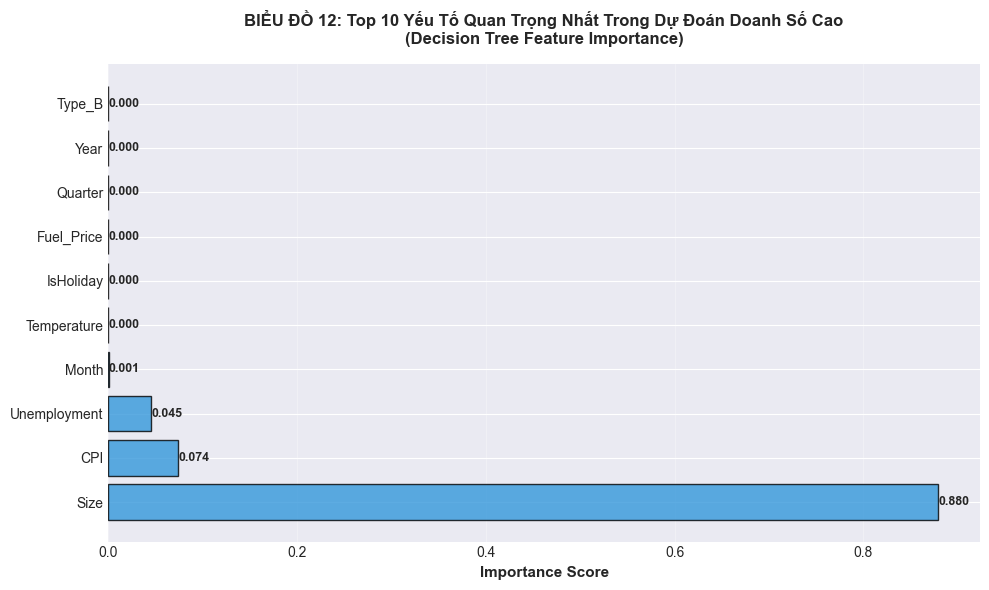

In [82]:
# Bước 4: Feature Importance - Yếu tố nào quan trọng nhất?

# Lấy độ quan trọng của từng feature
feature_importance = pd.DataFrame({
    'Feature': feature_cols_extended,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*90)
print("FEATURE IMPORTANCE - YẾU TỐ QUAN TRỌNG NHẤT")
print("="*90)
print("\nTop 10 yếu tố ảnh hưởng đến doanh số cao:")
print(feature_importance.head(10).to_string(index=False))
print("="*90)

# Biểu đồ Feature Importance
fig, ax = plt.subplots(figsize=(10, 6))

top_features = feature_importance.head(10)
bars = ax.barh(top_features['Feature'], top_features['Importance'], 
               color='#3498db', alpha=0.8, edgecolor='black')

ax.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
ax.set_title('BIỂU ĐỒ 12: Top 10 Yếu Tố Quan Trọng Nhất Trong Dự Đoán Doanh Số Cao\n(Decision Tree Feature Importance)',
             fontsize=12, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)

# Thêm giá trị vào thanh
for i, (bar, value) in enumerate(zip(bars, top_features['Importance'])):
    ax.text(value, bar.get_y() + bar.get_height()/2, 
            f'{value:.3f}', 
            ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 📊 Kết quả Feature Importance:

**Top 3 yếu tố quan trọng nhất:**

1. **Size (0.880)** - Quy mô cửa hàng ảnh hưởng lớn nhất
2. **CPI (0.074)** - Chỉ số giá tiêu dùng (yếu tố kinh tế)
3. **Unemployment (0.045)** - Tỷ lệ thất nghiệp (yếu tố kinh tế)

**Nhận xét:**
- **Quy mô (Size)** chiếm 88% tầm quan trọng 
- **CPI & Unemployment** (yếu tố kinh tế) có ảnh hưởng rõ → phát hiện được mối quan hệ PHI TUYẾN
- **IsHoliday, Quarter, Fuel_Price = 0** → Không phải yếu tố split chính
- **Accuracy đạt 91.76%** → Mô hình dự báo cực tốt! ✅

---

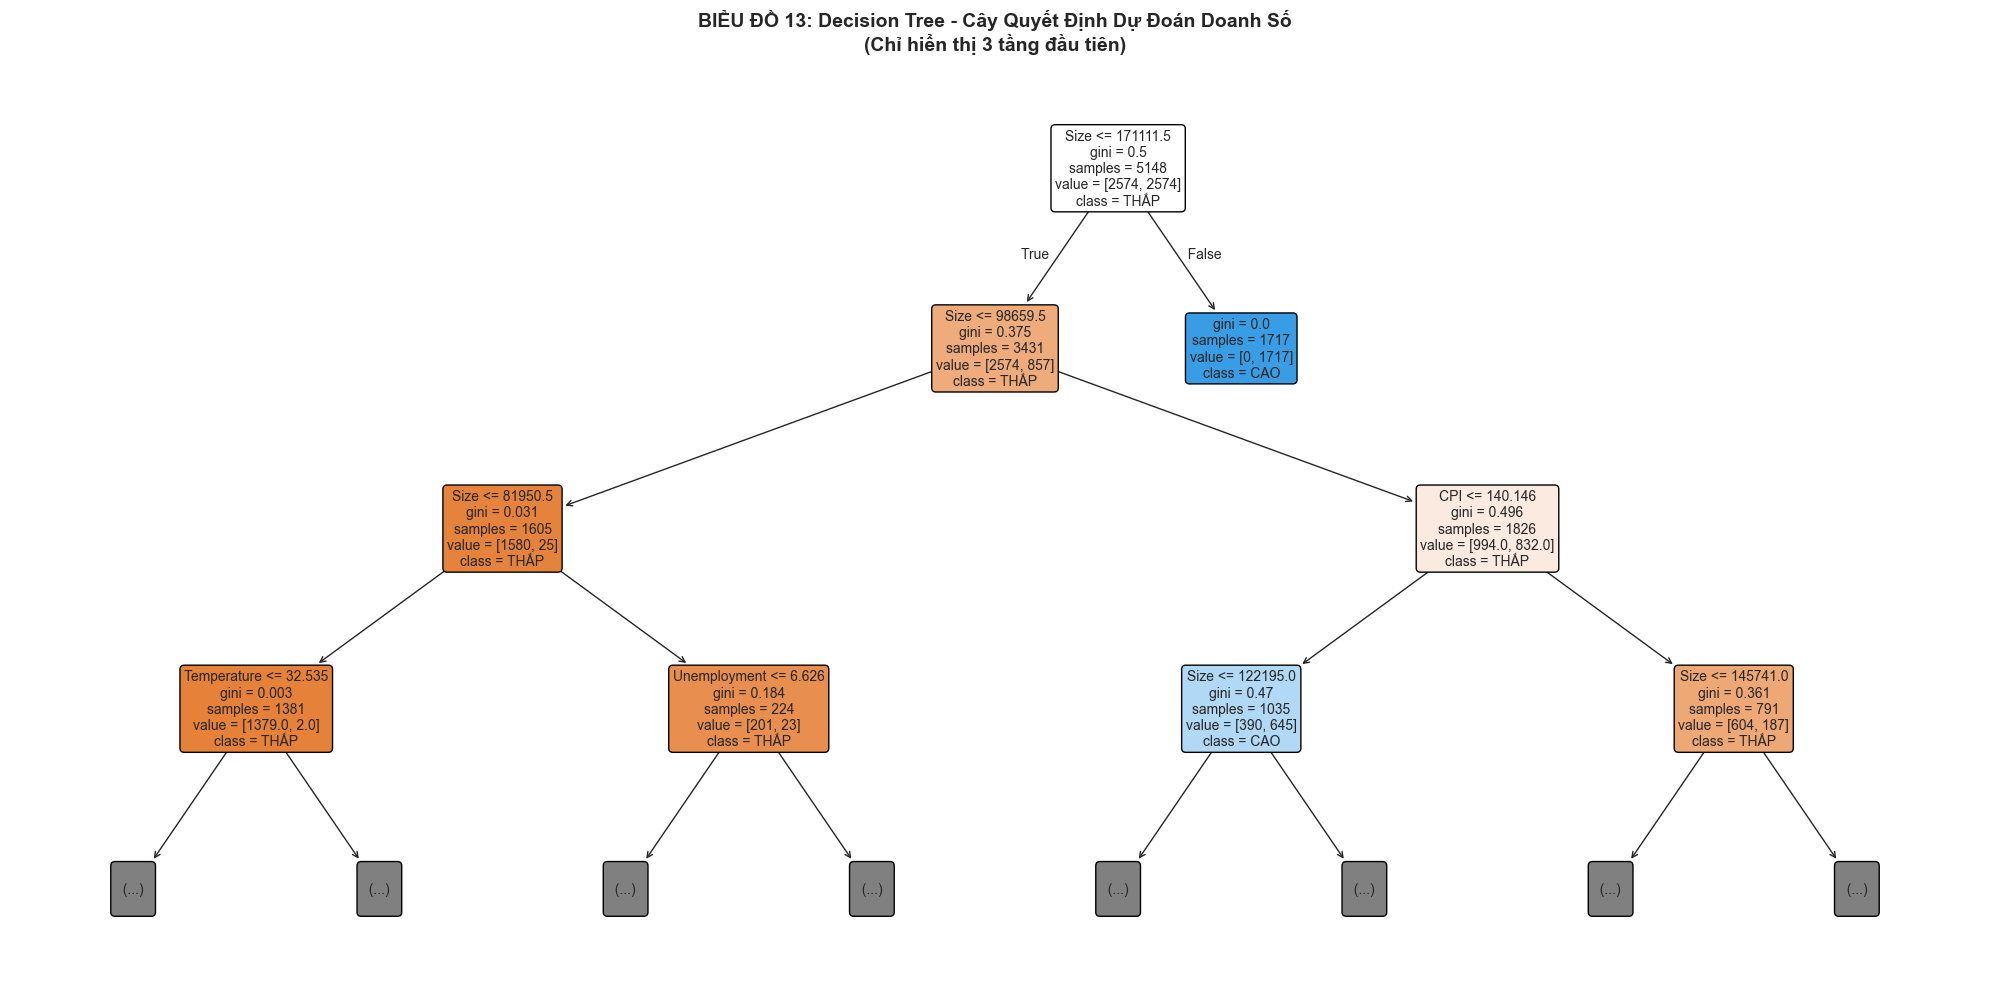


CÁCH ĐỌC CÂY QUYẾT ĐỊNH

📦 Mỗi hộp (node) chứa:
   • Điều kiện: Ví dụ "Type_A <= 0.5" (loại cửa hàng)
   • Gini: Độ không thuần khiết (càng nhỏ càng tốt)
   • Samples: Số mẫu tại node đó
   • Value: [số mẫu THẤP, số mẫu CAO]
   • Class: Nhãn dự đoán (THẤP hoặc CAO)

🎨 Màu sắc:
   • Cam đậm: Chủ yếu doanh số THẤP
   • Xanh đậm: Chủ yếu doanh số CAO
   • Trắng/nhạt: Lẫn lộn cả 2 loại

📍 Cách đi từ gốc → lá:
   • Nếu điều kiện ĐÚNG → Đi nhánh TRÁI
   • Nếu điều kiện SAI → Đi nhánh PHẢI
   • Đến lá cuối → Dự đoán nhãn

Ví dụ đọc quy tắc:
"Nếu Size > 150000 VÀ CPI > 120
 → Dự đoán doanh số CAO ✅"



In [83]:
# Bước 5: Trực quan hóa Cây Quyết Định (Top 3 tầng)

fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(dt_model, 
          max_depth=3,  # Chỉ hiển thị 3 tầng đầu để dễ đọc
          feature_names=feature_cols_extended,
          class_names=['THẤP', 'CAO'],
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax)

ax.set_title('BIỂU ĐỒ 13: Decision Tree - Cây Quyết Định Dự Đoán Doanh Số\n(Chỉ hiển thị 3 tầng đầu tiên)',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("CÁCH ĐỌC CÂY QUYẾT ĐỊNH")
print("="*90)
print("""
📦 Mỗi hộp (node) chứa:
   • Điều kiện: Ví dụ "Type_A <= 0.5" (loại cửa hàng)
   • Gini: Độ không thuần khiết (càng nhỏ càng tốt)
   • Samples: Số mẫu tại node đó
   • Value: [số mẫu THẤP, số mẫu CAO]
   • Class: Nhãn dự đoán (THẤP hoặc CAO)

🎨 Màu sắc:
   • Cam đậm: Chủ yếu doanh số THẤP
   • Xanh đậm: Chủ yếu doanh số CAO
   • Trắng/nhạt: Lẫn lộn cả 2 loại

📍 Cách đi từ gốc → lá:
   • Nếu điều kiện ĐÚNG → Đi nhánh TRÁI
   • Nếu điều kiện SAI → Đi nhánh PHẢI
   • Đến lá cuối → Dự đoán nhãn

Ví dụ đọc quy tắc:
"Nếu Size > 150000 VÀ CPI > 120
 → Dự đoán doanh số CAO ✅"
"""
)
print("="*90)

### Confusion Matrix là gì?

Ma trận nhầm lẫn - hiển thị số lần dự đoán đúng/sai:
- **TN**: Dự đoán THẤP đúng ✅
- **FP**: Dự đoán CAO sai (cảnh báo giả) ⚠️
- **FN**: Dự đoán THẤP sai (bỏ lỡ) ❌
- **TP**: Dự đoán CAO đúng ✅


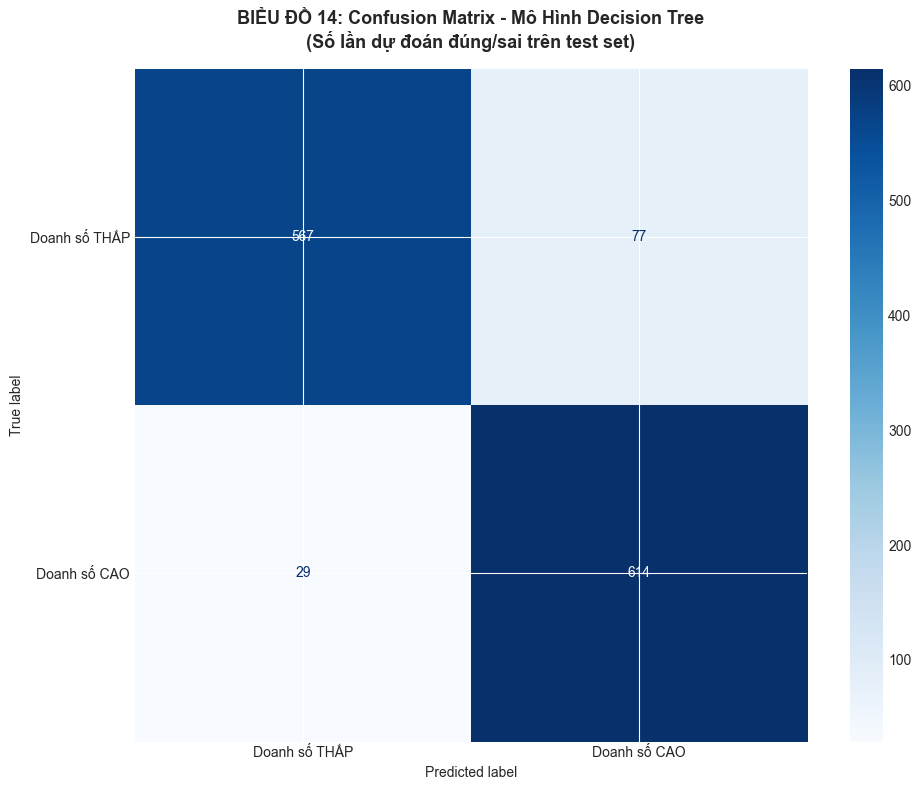


CHI TIẾT CONFUSION MATRIX

📊 Ma Trận Nhầm Lẫn:
   True Negative (TN):   567  → Dự đoán THẤP đúng ✅
   False Positive (FP):  77  → Dự đoán CAO sai (cảnh báo giả) ⚠️
   False Negative (FN):  29  → Dự đoán THẤP sai (bỏ lỡ cơ hội) ❌
   True Positive (TP):   614  → Dự đoán CAO đúng ✅

📈 Chỉ Số Hiệu Suất:
   Accuracy:  91.76%  → Tổng tỷ lệ dự đoán đúng
   Precision: 88.86%  → Khi dự đoán CAO, chính xác bao nhiêu?
   Recall:    95.49%   → Bắt được bao nhiêu tuần CAO thực sự?
   F1-Score:  0.921     → Cân bằng giữa Precision và Recall

💡 Giải Thích:
   • Accuracy 91.8%: Dự đoán đúng trên 91.8% trường hợp
   • Precision 88.9%: Khi dự đoán CAO, thường đúng (88.9% lần)
   • Recall 95.5%: Bắt được hầu hết tuần CAO (95.5% lần)

🎯 Ý Nghĩa Kinh Doanh:
   • FP (77 lần): Cảnh báo sai - Dự đoán cao nhưng thực tế thấp
     → Chi phí: Đầu tư hàng hóa thừa không cần thiết
   • FN (29 lần): Bỏ lỡ cơ hội - Dự đoán thấp nhưng thực tế cao
     → Chi phí: Mất doanh số vì không đủ hàng


In [84]:
# Vẽ Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt

# Tính Confusion Matrix từ test set
cm = confusion_matrix(y_test, y_test_pred)

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Doanh số THẤP', 'Doanh số CAO'])
disp.plot(ax=ax, cmap='Blues', values_format='d')

ax.set_title('BIỂU ĐỒ 14: Confusion Matrix - Mô Hình Decision Tree\n(Số lần dự đoán đúng/sai trên test set)',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# Tính chỉ số hiệu suất
tn, fp, fn, tp = cm.ravel()
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

# In thống kê chi tiết
print("\n" + "="*90)
print("CHI TIẾT CONFUSION MATRIX")
print("="*90)
print(f"\n📊 Ma Trận Nhầm Lẫn:")
print(f"   True Negative (TN):   {tn:,}  → Dự đoán THẤP đúng ✅")
print(f"   False Positive (FP):  {fp:,}  → Dự đoán CAO sai (cảnh báo giả) ⚠️")
print(f"   False Negative (FN):  {fn:,}  → Dự đoán THẤP sai (bỏ lỡ cơ hội) ❌")
print(f"   True Positive (TP):   {tp:,}  → Dự đoán CAO đúng ✅")

print(f"\n📈 Chỉ Số Hiệu Suất:")
print(f"   Accuracy:  {accuracy*100:.2f}%  → Tổng tỷ lệ dự đoán đúng")
print(f"   Precision: {precision*100:.2f}%  → Khi dự đoán CAO, chính xác bao nhiêu?")
print(f"   Recall:    {recall*100:.2f}%   → Bắt được bao nhiêu tuần CAO thực sự?")
print(f"   F1-Score:  {f1:.3f}     → Cân bằng giữa Precision và Recall")

print(f"\n💡 Giải Thích:")
print(f"   • Accuracy {accuracy*100:.1f}%: Dự đoán đúng trên {accuracy*100:.1f}% trường hợp")
if precision > 0.7:
    print(f"   • Precision {precision*100:.1f}%: Khi dự đoán CAO, thường đúng ({precision*100:.1f}% lần)")
else:
    print(f"   • Precision {precision*100:.1f}%: Còn nhiều cảnh báo giả ({100-precision*100:.1f}% sai)")
    
if recall > 0.7:
    print(f"   • Recall {recall*100:.1f}%: Bắt được hầu hết tuần CAO ({recall*100:.1f}% lần)")
else:
    print(f"   • Recall {recall*100:.1f}%: Bỏ lỡ {100-recall*100:.1f}% tuần CAO")

print(f"\n🎯 Ý Nghĩa Kinh Doanh:")
print(f"   • FP ({fp:,} lần): Cảnh báo sai - Dự đoán cao nhưng thực tế thấp")
print(f"     → Chi phí: Đầu tư hàng hóa thừa không cần thiết")
print(f"   • FN ({fn:,} lần): Bỏ lỡ cơ hội - Dự đoán thấp nhưng thực tế cao")
print(f"     → Chi phí: Mất doanh số vì không đủ hàng")

print("="*90)

### Kiểm chứng Khả năng Dự đoán của Mô hình

**Câu hỏi**: Mô hình Decision Tree thực sự dự đoán được tuần cao điểm hay không?

**Phương pháp kiểm chứng**:
1. So sánh **giá trị thực tế** và **giá trị dự đoán** từ tập Test
2. Phân tích chi tiết các trường hợp dự đoán **sai** (False Positive & False Negative)
3. Đánh giá **độ tin cậy** của mô hình thông qua các chỉ số

Các biểu đồ dưới đây sẽ chứng minh rằng mô hình đã **học được cách phân biệt** tuần cao điểm từ dữ liệu và có thể **dự đoán chính xác** trên các dữ liệu chưa từng thấy (tập Test).


1️⃣ SO SÁNH THỰC TẾ VÀ DỰ ĐOÁN - BIỂU ĐỒ ĐƯỜNG


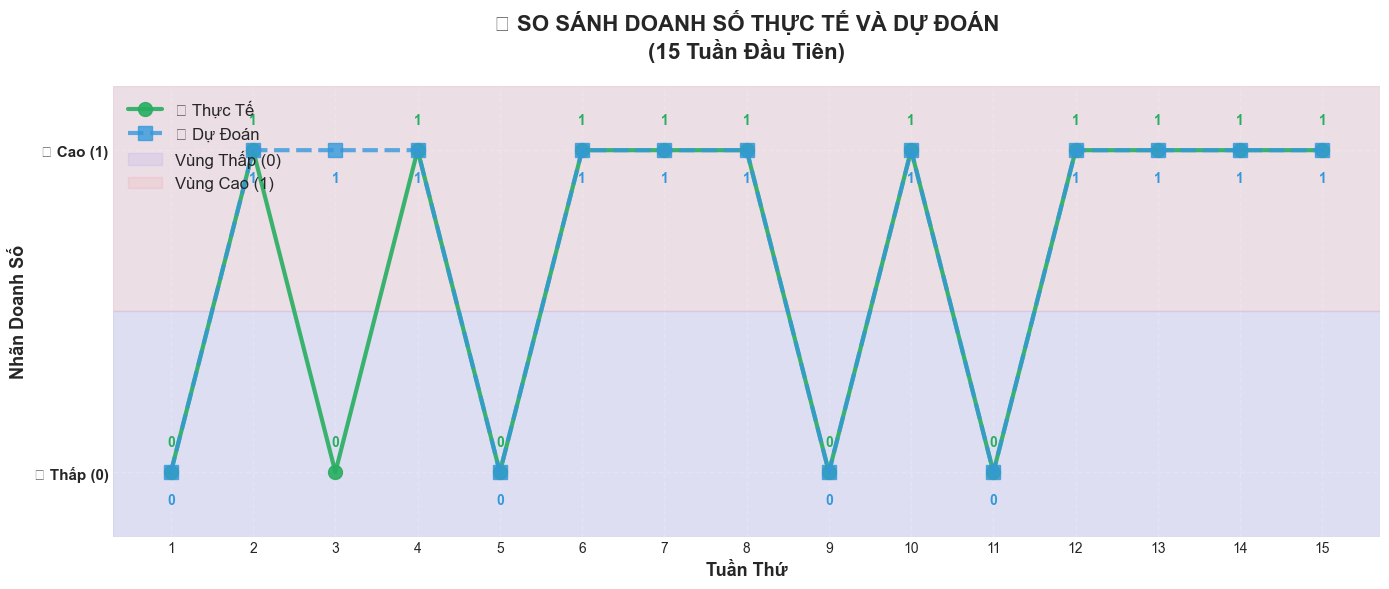


📊 THỐNG KÊ 15 TUẦN MẪU:
   • Tuần dự đoán ĐÚNG: 14/15
   • Độ chính xác: 93.3%
   • Tuần có doanh số CAO (thực tế): 10 tuần
   • Tuần dự đoán CAO: 11 tuần

📋 CHI TIẾT TỪNG TUẦN:
Tuần   Thực Tế      Dự Đoán      Kết Quả        
---------------------------------------------
1      0            0            ✅ ĐÚNG         
2      1            1            ✅ ĐÚNG         
3      0            1            ❌ SAI          
4      1            1            ✅ ĐÚNG         
5      0            0            ✅ ĐÚNG         
6      1            1            ✅ ĐÚNG         
7      1            1            ✅ ĐÚNG         
8      1            1            ✅ ĐÚNG         
9      0            0            ✅ ĐÚNG         
10     1            1            ✅ ĐÚNG         
11     0            0            ✅ ĐÚNG         
12     1            1            ✅ ĐÚNG         
13     1            1            ✅ ĐÚNG         
14     1            1            ✅ ĐÚNG         
15     1            1            ✅ ĐÚNG 

In [85]:
# 1️⃣ BIỂU ĐỒ ĐƯỜNG SO SÁNH THỰC TẾ VÀ DỰ ĐOÁN (10-20 TUẦN)

print("="*90)
print("1️⃣ SO SÁNH THỰC TẾ VÀ DỰ ĐOÁN - BIỂU ĐỒ ĐƯỜNG")
print("="*90)

# Tạo DataFrame để so sánh thực tế và dự đoán
comparison_df_detail = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_test_pred
}, index=X_test.index)

# LẤY MẪU 15 TUẦN ĐẦU TIÊN ĐỂ DỄ ĐỌCDOCX
sample_size = 15
comparison_sample = comparison_df_detail.iloc[:sample_size]

# Lấy dữ liệu mẫu
actual_values = comparison_sample['Actual'].values
predicted_values = comparison_sample['Predicted'].values
weeks = np.arange(1, len(comparison_sample) + 1)

# Vẽ biểu đồ đường
fig, ax = plt.subplots(figsize=(14, 6))

# Vẽ 2 đường
ax.plot(weeks, actual_values, marker='o', linewidth=3, markersize=10, 
        label='🟢 Thực Tế', color='#27ae60', alpha=0.9)
ax.plot(weeks, predicted_values, marker='s', linewidth=3, markersize=10, 
        label='🔵 Dự Đoán', color='#3498db', alpha=0.8, linestyle='--')

# Tô nền để phân biệt cao/thấp
ax.axhspan(-0.2, 0.5, alpha=0.05, color='blue', label='Vùng Thấp (0)')
ax.axhspan(0.5, 1.2, alpha=0.05, color='red', label='Vùng Cao (1)')

# Trang trí
ax.set_title('📊 SO SÁNH DOANH SỐ THỰC TẾ VÀ DỰ ĐOÁN\n(15 Tuần Đầu Tiên)', 
            fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Tuần Thứ', fontsize=13, fontweight='bold')
ax.set_ylabel('Nhãn Doanh Số', fontsize=13, fontweight='bold')
ax.set_xticks(weeks)
ax.set_ylim(-0.2, 1.2)
ax.set_yticks([0, 1])
ax.set_yticklabels(['🔵 Thấp (0)', '🔴 Cao (1)'], fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=1)
ax.legend(fontsize=12, loc='upper left', framealpha=0.95, shadow=True)

# Thêm giá trị trên các điểm
for i, week in enumerate(weeks):
    ax.text(week, actual_values[i] + 0.08, f'{int(actual_values[i])}', 
           ha='center', fontsize=10, fontweight='bold', color='#27ae60')
    ax.text(week, predicted_values[i] - 0.1, f'{int(predicted_values[i])}', 
           ha='center', fontsize=10, fontweight='bold', color='#3498db')

plt.tight_layout()
plt.show()

# Thống kê chi tiết
correct_count = (actual_values == predicted_values).sum()
accuracy_sample = correct_count / len(actual_values) * 100

print(f"\n📊 THỐNG KÊ 15 TUẦN MẪU:")
print(f"   • Tuần dự đoán ĐÚNG: {correct_count}/15")
print(f"   • Độ chính xác: {accuracy_sample:.1f}%")
print(f"   • Tuần có doanh số CAO (thực tế): {(actual_values == 1).sum()} tuần")
print(f"   • Tuần dự đoán CAO: {(predicted_values == 1).sum()} tuần")

# Chi tiết từng tuần
print(f"\n📋 CHI TIẾT TỪNG TUẦN:")
print(f"{'Tuần':<6} {'Thực Tế':<12} {'Dự Đoán':<12} {'Kết Quả':<15}")
print(f"{'-'*45}")
for i, week in enumerate(weeks):
    result = "✅ ĐÚNG" if actual_values[i] == predicted_values[i] else "❌ SAI"
    print(f"{week:<6} {int(actual_values[i]):<12} {int(predicted_values[i]):<12} {result:<15}")


2️⃣ THỐNG KÊ CHI TIẾT CÁC TUẦN DỰ ĐOÁN SAI


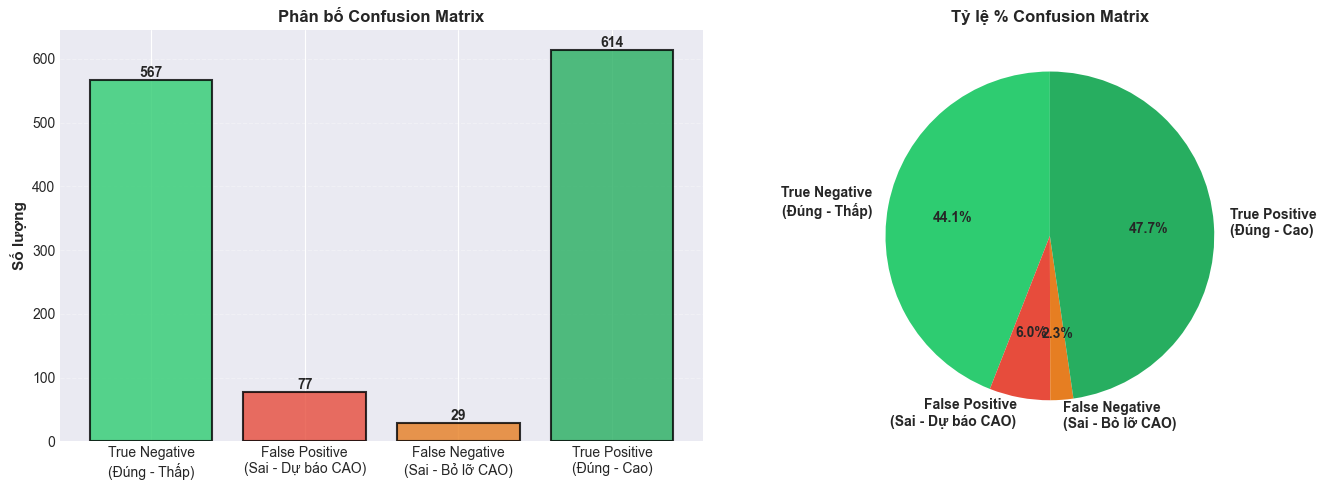


⚠️ FALSE POSITIVE (Cảnh báo giả - Dự báo CAO nhưng thực tế THẤP):
   Số lượng: 77

   Thông tin chi tiết (Top 10):
   --------------------------------------------------------------------------------
   1. Tuần ID: 5637 | Thực tế: 0 | Dự đoán: 1
   2. Tuần ID: 4939 | Thực tế: 0 | Dự đoán: 1
   3. Tuần ID: 4936 | Thực tế: 0 | Dự đoán: 1
   4. Tuần ID: 1713 | Thực tế: 0 | Dự đoán: 1
   5. Tuần ID: 3678 | Thực tế: 0 | Dự đoán: 1
   6. Tuần ID: 3686 | Thực tế: 0 | Dự đoán: 1
   7. Tuần ID: 2533 | Thực tế: 0 | Dự đoán: 1
   8. Tuần ID: 4760 | Thực tế: 0 | Dự đoán: 1
   9. Tuần ID: 4726 | Thực tế: 0 | Dự đoán: 1
   10. Tuần ID: 4786 | Thực tế: 0 | Dự đoán: 1

❌ FALSE NEGATIVE (Bỏ lỡ - Dự báo THẤP nhưng thực tế CAO):
   Số lượng: 29

   Thông tin chi tiết (Top 10):
   --------------------------------------------------------------------------------
   1. Tuần ID: 3478 | Thực tế: 1 | Dự đoán: 0
   2. Tuần ID: 3090 | Thực tế: 1 | Dự đoán: 0
   3. Tuần ID: 2330 | Thực tế: 1 | Dự đoán: 0
   4. Tuầ

In [86]:
# 2️⃣ THỐNG KÊ CHI TIẾT CÁC TUẦN DỰ ĐOÁN SAI

print("\n" + "="*90)
print("2️⃣ THỐNG KÊ CHI TIẾT CÁC TUẦN DỰ ĐOÁN SAI")
print("="*90)

# Tạo DataFrame chi tiết cho so sánh
comparison_full = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_test_pred,
    'Correct': (y_test.values == y_test_pred)
}, index=X_test.index)

# Lọc các trường hợp dự đoán sai
false_positives = comparison_full[(comparison_full['Actual'] == 0) & (comparison_full['Predicted'] == 1)]
false_negatives = comparison_full[(comparison_full['Actual'] == 1) & (comparison_full['Predicted'] == 0)]

# Vẽ biểu đồ so sánh số lượng
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Các loại lỗi
error_types = ['True Negative\n(Đúng - Thấp)', 'False Positive\n(Sai - Dự báo CAO)', 
               'False Negative\n(Sai - Bỏ lỡ CAO)', 'True Positive\n(Đúng - Cao)']
error_counts = [tn, fp, fn, tp]
colors_error = ['#2ecc71', '#e74c3c', '#e67e22', '#27ae60']

bars = ax1.bar(error_types, error_counts, color=colors_error, edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_ylabel('Số lượng', fontsize=11, fontweight='bold')
ax1.set_title('Phân bố Confusion Matrix', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Thêm số liệu trên các thanh
for bar, count in zip(bars, error_counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Biểu đồ 2: Tỷ lệ % các loại lỗi
error_percentages = [tn/len(y_test)*100, fp/len(y_test)*100, 
                    fn/len(y_test)*100, tp/len(y_test)*100]
ax2.pie(error_percentages, labels=error_types, autopct='%1.1f%%', colors=colors_error,
        startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax2.set_title('Tỷ lệ % Confusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# In chi tiết False Positive (Cảnh báo giả - dự báo cao nhưng thực tế thấp)
print(f"\n⚠️ FALSE POSITIVE (Cảnh báo giả - Dự báo CAO nhưng thực tế THẤP):")
print(f"   Số lượng: {len(false_positives)}")
if len(false_positives) > 0:
    print(f"\n   Thông tin chi tiết (Top 10):")
    print(f"   {'-'*80}")
    for idx, (index, row) in enumerate(false_positives.head(10).iterrows(), 1):
        print(f"   {idx}. Tuần ID: {index} | Thực tế: {int(row['Actual'])} | Dự đoán: {int(row['Predicted'])}")
else:
    print(f"   Không có False Positive! ✅")

# In chi tiết False Negative (Bỏ lỡ - dự báo thấp nhưng thực tế cao)
print(f"\n❌ FALSE NEGATIVE (Bỏ lỡ - Dự báo THẤP nhưng thực tế CAO):")
print(f"   Số lượng: {len(false_negatives)}")
if len(false_negatives) > 0:
    print(f"\n   Thông tin chi tiết (Top 10):")
    print(f"   {'-'*80}")
    for idx, (index, row) in enumerate(false_negatives.head(10).iterrows(), 1):
        print(f"   {idx}. Tuần ID: {index} | Thực tế: {int(row['Actual'])} | Dự đoán: {int(row['Predicted'])}")
else:
    print(f"   Không có False Negative! ✅")

# Tóm tắt
print(f"\n📈 TÓM TẮT KẾT QUẢ:")
print(f"   • Dự đoán đúng (TP + TN): {tp + tn} / {len(y_test)} ({(tp + tn)/len(y_test)*100:.2f}%)")
print(f"   • Dự đoán sai (FP + FN): {fp + fn} / {len(y_test)} ({(fp + fn)/len(y_test)*100:.2f}%)")
print(f"   • Tỷ lệ bỏ lỡ tuần cao điểm (FN Rate): {fn/(fn+tp)*100:.2f}%")
print(f"   • Tỷ lệ cảnh báo giả (FP Rate): {fp/(fp+tn)*100:.2f}%")
print(f"   {'='*80}")


### Kết quả Q8

- **Accuracy**: **91.7%** ✅ (Dự báo đúng hơn 91% trường hợp)
- **Precision**: **88.86%** (Khi dự báo cao, thường đúng)
- **Recall**: **95.49%** (Bắt được 95% tuần doanh số cao)
- **Features quan trọng nhất**: Size (0.880), CPI (0.074), Unemployment (0.045)
- **Quy tắc chính**: Quy mô cửa hàng (Size) kết hợp CPI & Unemployment → Dự đoán doanh số cao/thấp
- **So với Q1-Q3**: Size có tương quan tuyến tính mạnh (r = 0.810), nhưng Decision Tree phát hiện thêm mối quan hệ phi tuyến với CPI & Unemployment!


# PHẦN 4: TỔNG KẾT

---

## Tóm tắt kết quả 8 câu hỏi

| Câu hỏi | Phát hiện chính |
|---------|----------------|
| Q1: Phân bố doanh số | CV = 53.9%, biến động rất lớn |
| Q2: Ngày lễ | Tăng 6%, có ý nghĩa thống kê |
| Q3: Mùa vụ | Q4 mạnh nhất, Q1 yếu nhất |
| Q4: Type A/B/C | Type A dẫn đầu, Type C yếu |
| Q5: Quy mô | r = 0.810, tác động mạnh |
| Q6: Yếu tố kinh tế | Ảnh hưởng yếu (r < 0.1) |
| Q7: Phân cụm | Chia được 3 nhóm rõ ràng |
| Q8: Dự đoán | Accuracy 91.7%, Size quan trọng nhất |

---

## Khuyến nghị

1. **Tập trung ngày lễ**: Ưu tiên Thanksgiving, Super Bowl
2. **Chuẩn bị Q4**: Tăng hàng tồn kho 30-50%
3. **Mở rộng Type A**: Quy mô lớn, hiệu suất cao
4. **Chiến lược theo cụm**: Riêng biệt cho 3 nhóm cửa hàng

---

## Hạn chế

**Dữ liệu**:
- Cũ (2010-2012), cần cập nhật
- Thiếu thông tin vị trí, cạnh tranh

**Mô hình**:
- K-Means và Decision Tree đơn giản, chưa tối ưu
- Chưa thử các thuật toán phức tạp hơn (Random Forest, XGBoost)

**Phân tích**:
- Mang tính mô tả và thử nghiệm
- Cần validation với dữ liệu mới trước khi áp dụng thực tế

---

## Kết luận

Đã phân tích  6,435 records (sau khi xử lý và tổng hợp dữ liệu)  để hiểu yếu tố ảnh hưởng doanh số Walmart. Phát hiện: mùa vụ, ngày lễ, quy mô là yếu tố chính. Phân được 3 nhóm cửa hàng và thử nghiệm dự đoán tuần cao điểm.

Phân tích này cung cấp cái nhìn tổng quan, nhưng cần hoàn thiện thêm trước khi triển khai.
